
<div style="
background:linear-gradient(90deg,#0f172a,#1e3a8a);
padding:25px;
border-radius:12px;
color:white;
text-align:center;
">

<h1>🏠 Egyptian Real Estate Market</h1>

<h3>Exploratory Data Analysis (EDA)</h3>

<p>
A data-driven analysis of active real estate listings across Egypt's major regions,
uncovering pricing patterns, property characteristics, and market segmentation to
inform investment and pricing strategy.
</p>

</div>





##
<div style="
background:#f8fafc;
border-left:6px solid #0ea5e9;
padding:18px;
border-radius:10px;
">

<h2 style="color:#0369a1;">
📚 Libraries
</h2>

<p>
Core Python libraries used for data manipulation, numerical computation,
and visualization throughout this analysis.
</p>

</div>


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
##
<div style="
background:#eef2ff;
border-left:6px solid #4f46e5;
padding:18px;
border-radius:10px;
">

<h2 style="color:#4338ca;">
📂 Load Dataset
</h2>

<p>
Load the preprocessed real estate listings dataset and preview its initial structure.
</p>

</div>


In [90]:
df = pd.read_csv('Data/preprocessed_data.csv')
df.head()

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
0,A Full Sea view chalet 3BR for sale in north c...,16400000,3,True,3,140,Chalet,2026-04-30,"June, Ras Al Hekma, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,4,30,117142.857143,9,6,5.466667e+06,5.466667e+06,46.666667,46.666667,1.500000
1,Sea View Chalet 1BR In Fouka Bay Fully Finished,10500000,1,True,1,50,Chalet,2026-06-21,"Fouka Bay, Qesm Marsa Matrouh, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,21,210000.000000,9,2,1.050000e+07,1.050000e+07,50.000000,50.000000,4.500000
2,chalet 3bed ready to move prime location old p...,17500000,3,True,3,144,Chalet,2026-06-04,"Marassi, Sidi Abdel Rahman, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,4,121527.777778,9,6,5.833333e+06,5.833333e+06,48.000000,48.000000,1.500000
3,apartment 2bed for sale ready to move old price !,5000000,2,True,2,108,Apartment,2026-06-16,"Zed East, 5th Settlement Compounds, The 5th Se...","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,16,46296.296296,9,4,2.500000e+06,2.500000e+06,54.000000,54.000000,2.250000
4,First Row Armani Standalone Villa 5BR with 5% DP!,250000000,5,True,6,325,Villa,2026-06-22,"Silver Sands, Qesm Marsa Matrouh, North Coast","Partly furnished, Balcony, Built in Wardrobes,...",...,6,22,769230.769231,9,11,5.000000e+07,4.166667e+07,65.000000,54.166667,0.818182


---
##
<div style="
background:#ecfeff;
border-left:6px solid #06b6d4;
padding:18px;
border-radius:10px;
">

<h2 style="color:#0e7490;">
📊 1. Dataset Overview
</h2>

<p>
Establish the dataset's size, structure, and feature composition before proceeding
to quality checks and deeper analysis.
</p>

</div>


In [91]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 919
Columns: 45


**Column Data Types**

In [92]:
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)
print()
df.dtypes

int64      28
str        10
float64     6
bool        1
Name: count, dtype: int64



title                             str
price                           int64
bedrooms                        int64
has_maid_room                    bool
bathrooms                       int64
area_sqm                        int64
property_type                     str
available_from                    str
location                          str
amenities                         str
area_sqft                       int64
region                            str
sub_area                          str
furnishing_status                 str
amenities_no_furnishing           str
amenities_clean_list              str
amenity_balcony                 int64
amenity_built_in_wardrobes      int64
amenity_central_a_c             int64
amenity_children's_pool         int64
amenity_covered_parking         int64
amenity_kitchen_appliances      int64
amenity_lobby_in_building       int64
amenity_maids_room              int64
amenity_private_garden          int64
amenity_private_pool            int64
amenity_secu

**Sample Records (First and Last Rows)**

In [93]:
df.head(3)

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
0,A Full Sea view chalet 3BR for sale in north c...,16400000,3,True,3,140,Chalet,2026-04-30,"June, Ras Al Hekma, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,4,30,117142.857143,9,6,5.466667e+06,5.466667e+06,46.666667,46.666667,1.5
1,Sea View Chalet 1BR In Fouka Bay Fully Finished,10500000,1,True,1,50,Chalet,2026-06-21,"Fouka Bay, Qesm Marsa Matrouh, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,21,210000.000000,9,2,1.050000e+07,1.050000e+07,50.000000,50.000000,4.5
2,chalet 3bed ready to move prime location old p...,17500000,3,True,3,144,Chalet,2026-06-04,"Marassi, Sidi Abdel Rahman, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,4,121527.777778,9,6,5.833333e+06,5.833333e+06,48.000000,48.000000,1.5


In [94]:
df.tail(3)

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
916,First Row Villa | Fully Finished & 5% Downpayment,29800000,4,True,5,360,Villa,2026-06-18,"Ras Soma, Safaga, Hurghada, Red Sea","Partly furnished, Balcony, Built in Wardrobes,...",...,6,18,82777.777778,9,9,7.450000e+06,5960000.0,90.0,72.0,1.000000
917,1st row Fully Finished chalet with only 5% DP,13200000,3,True,4,180,Chalet,2026-06-21,"Almaza Bay, Qesm Marsa Matrouh, North Coast","Partly furnished, Balcony, Built in Wardrobes,...",...,6,21,73333.333333,9,7,4.400000e+06,3300000.0,60.0,45.0,1.285714
918,Last Chalet Premium Seaview on 10Y Installments,18200000,3,True,4,210,Chalet,2026-06-18,"Ras Soma, Safaga, Hurghada, Red Sea","Partly furnished, Balcony, Built in Wardrobes,...",...,6,18,86666.666667,9,7,6.066667e+06,4550000.0,70.0,52.5,1.285714


**Summary Statistics —> Numerical Features**

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,919.0,2.833054e+07,5.420071e+07,3.300000e+06,1.230000e+07,1.700000e+07,2.500000e+07,9.000000e+08
bedrooms,919.0,3.022851e+00,1.175513e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00
bathrooms,919.0,3.210011e+00,1.220052e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00
area_sqm,919.0,2.163330e+02,2.378990e+02,3.800000e+01,1.270000e+02,1.640000e+02,2.305000e+02,4.000000e+03
area_sqft,919.0,2.328587e+03,2.560736e+03,4.090000e+02,1.367000e+03,1.765000e+03,2.481000e+03,4.305600e+04
amenity_balcony,919.0,9.630033e-01,1.888565e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_built_in_wardrobes,919.0,8.509249e-01,3.563564e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_central_a_c,919.0,8.857454e-01,3.182935e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_children's_pool,919.0,2.176279e-02,1.459875e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
amenity_covered_parking,919.0,9.423286e-01,2.332479e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


**Summary Statistics —> Categorical Features**

In [96]:
df.describe(include=['object', 'category']).T

C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_7844\2415731472.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object', 'category']).T


,count,unique,top,freq
title,919,753,Villa Finished On Lagoon Early Delivery Over 8...,15
property_type,919,10,Chalet,417
available_from,919,23,2026-06-22,375
location,919,112,"June, Ras Al Hekma, North Coast",60
amenities,919,331,"Unfurnished, Balcony, Built in Wardrobes, Cent...",258
region,919,5,North Coast,485
sub_area,919,112,June,60
furnishing_status,919,4,Unfurnished,469
amenities_no_furnishing,919,297,"Balcony, Built in Wardrobes, Central A/C, Cove...",409
amenities_clean_list,919,297,"['Balcony', 'Built In Wardrobes', 'Central A/C...",409


### 🔑 Key Insights — Dataset Overview

The dataset contains **919 property listings** across **45 features**, covering five major Egyptian regions: **North Coast, Cairo, Red Sea, Giza, and Suez**. It is already a **preprocessed dataset**, combining both raw listing attributes (e.g., price, area, bedrooms, bathrooms, property type, and location) and engineered features such as `price_per_sqm`, `amenities_count`, `price_per_bedroom`, and `area_per_bedroom`.

The feature set includes numerical variables, categorical variables, binary amenity indicators, and free-text fields, providing a rich foundation for both descriptive analysis and predictive modeling.

Overall, the dataset is well-structured and sufficiently comprehensive to support detailed market analysis, feature engineering, and machine learning tasks.

> **Next Step:** Before exploring market trends, the dataset quality is assessed to identify any issues that could affect the reliability of the analysis.


---
##
<div style="
background:#fef2f2;
border-left:6px solid #dc2626;
padding:18px;
border-radius:10px;
">

<h2 style="color:#b91c1c;">
🔍 2. Data Quality Assessment
</h2>

<p>
Evaluate missing values, duplicate records, invalid entries, and outliers to confirm
the dataset is reliable for downstream analysis.
</p>

</div>


In [97]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in any column.")

Missing values per column:
No missing values found in any column.


In [98]:
duplicate_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {duplicate_rows}")

Fully duplicate rows: 0


In [99]:
invalid_checks = {
    'price <= 0': (df['price'] <= 0).sum(),
    'area_sqm <= 0': (df['area_sqm'] <= 0).sum(),
    'bedrooms <= 0': (df['bedrooms'] <= 0).sum(),
    'bathrooms <= 0': (df['bathrooms'] <= 0).sum(),
    'bathrooms > bedrooms * 3': (df['bathrooms'] > df['bedrooms'] * 3).sum()
}
for check, count in invalid_checks.items():
    print(f"{check}: {count}")

price <= 0: 0
area_sqm <= 0: 0
bedrooms <= 0: 0
bathrooms <= 0: 0
bathrooms > bedrooms * 3: 0


In [100]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['price', 'area_sqm', 'price_per_sqm', 'bedrooms', 'bathrooms']:
    print(f"{col}: {iqr_outlier_count(df[col])} outliers ")

price: 91 outliers 
area_sqm: 73 outliers 
price_per_sqm: 45 outliers 
bedrooms: 0 outliers 
bathrooms: 0 outliers 


### 🔑 Key Insights — Data Quality

The dataset is **structurally clean and analysis-ready**, with **no missing values** and **no fully duplicated records**. Most features are internally consistent, allowing the analysis to proceed without extensive data cleaning.

The primary quality considerations are:

- **`furnishing_status` contains an "Unknown" category** (86 listings, ~9%), representing unlabeled data rather than true missing values.
- **Suez includes only two listings**, making it statistically unreliable for regional comparisons and requiring caution during location-level analysis.
- **Price and area exhibit strong right-skewness**, driven by genuine luxury properties rather than data-entry errors. These observations are preserved and handled through logarithmic transformations and visualization techniques instead of removal.
- No inconsistencies were identified between the `area_sqm` and `area_sqft` measurements.

Overall, the dataset demonstrates high data quality, with only a few limitations that should be considered when interpreting regional statistics and extreme property values.

> **Next Step:** With data quality confirmed, the following section examines the distribution and statistical characteristics of each numerical feature.


---
##
<div style="
background:#faf5ff;
border-left:6px solid #9333ea;
padding:18px;
border-radius:10px;
">

<h2 style="color:#7e22ce;">
📈 3. Univariate Analysis
</h2>

<p>
Examine the distribution of key numerical and categorical features individually to
understand the shape and composition of the market before exploring relationships
between variables.
</p>

</div>




### 3.1 Numerical Features

Distribution shape, spread, and skewness of price, area, and room-count variables.


In [101]:
key_numerical = ['price', 'area_sqm', 'bedrooms', 'bathrooms', 'price_per_sqm', 'amenities_count']

stats_table = pd.DataFrame({
    'Mean': df[key_numerical].mean(),
    'Median': df[key_numerical].median(),
    'Std Dev': df[key_numerical].std(),
    'Skewness': df[key_numerical].skew(),
    'Kurtosis': df[key_numerical].kurt(),
    'Min': df[key_numerical].min(),
    'Max': df[key_numerical].max(),
})
stats_table.round(2)

,Mean,Median,Std Dev,Skewness,Kurtosis,Min,Max
price,28330536.06,17000000.00,54200714.54,10.57,150.67,3300000.00,9.000000e+08
area_sqm,216.33,164.00,237.90,10.03,143.58,38.00,4.000000e+03
bedrooms,3.02,3.00,1.18,0.94,1.63,1.00,7.000000e+00
bathrooms,3.21,3.00,1.22,0.87,1.19,1.00,7.000000e+00
price_per_sqm,117836.72,108333.33,63624.43,4.49,38.12,28695.65,8.615385e+05
amenities_count,8.90,9.00,1.00,-5.13,29.95,1.00,1.000000e+01


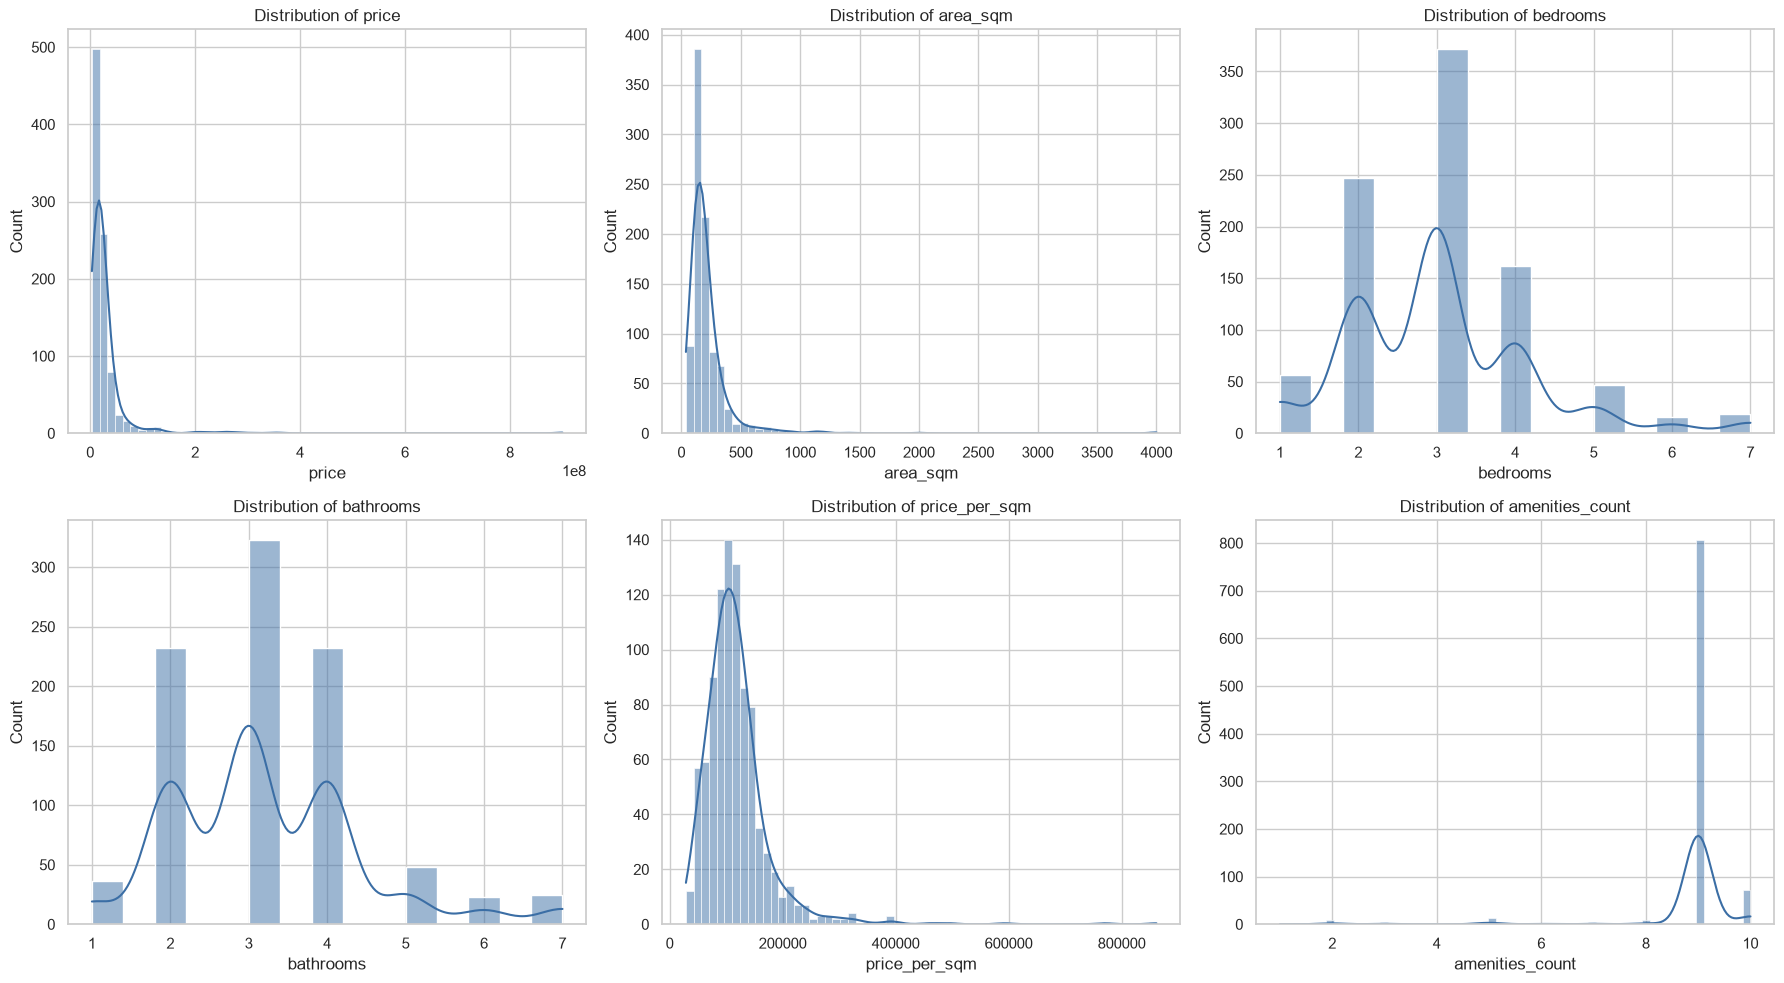

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3b6ea5')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

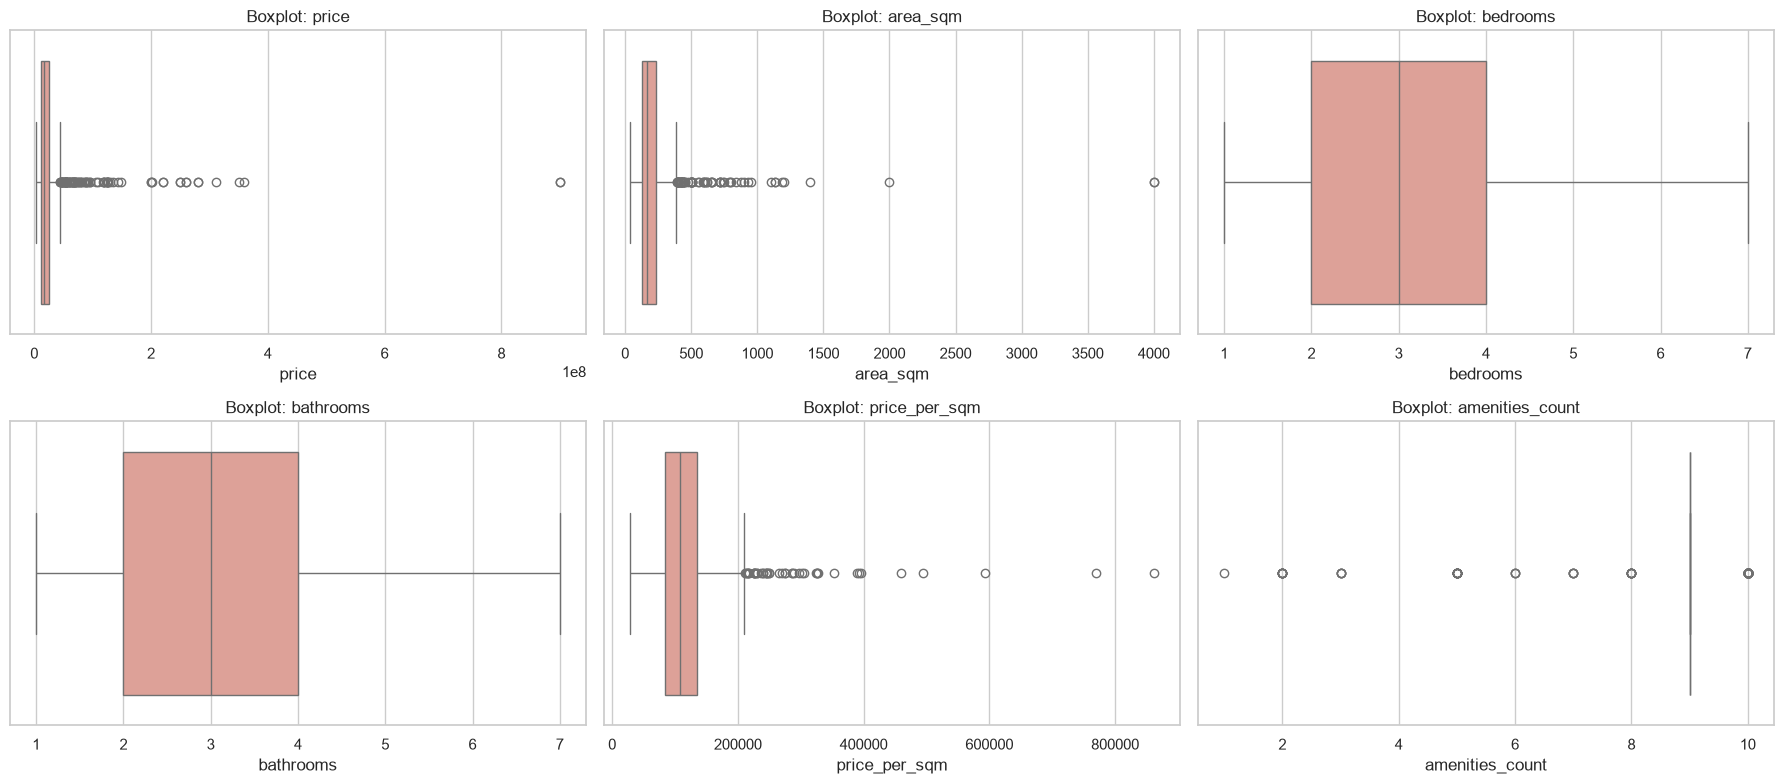

In [103]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.boxplot(x=df[col], ax=axes[i], color='#e8998d')
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

### 🔑 Key Insights — Numerical Features

The numerical variables reveal several characteristics typical of real estate datasets:

- **`price`** is highly right-skewed, with a long tail of luxury properties that raises the mean well above the median, indicating a premium market segment.
- **`area_sqm`** also exhibits strong right-skewness, driven by a relatively small number of exceptionally large luxury properties.
- **`bedrooms`** and **`bathrooms`** are discrete variables concentrated around 2–4 rooms, with fewer large residential properties extending the upper tail.
- **`price_per_sqm`** follows a more balanced distribution but still contains a noticeable right tail, suggesting significant location- and property-type premiums.
- **`amenities_count`** is tightly concentrated around 8–9 amenities, indicating that most listings provide a similar set of standard facilities.

Overall, the numerical distributions reveal the presence of skewness and genuine market outliers, reinforcing the need for robust statistical methods and logarithmic transformations in subsequent analyses.

> **Next Step:** After understanding the numerical variables, the analysis shifts to the distribution of categorical features to examine the composition of the property market.


### 3.2 Categorical Features

Composition of property type, region, and furnishing status across the listings.


In [104]:
cat_features = ['property_type', 'region', 'furnishing_status']

for col in cat_features:
    print(f"--- {col} ---")
    freq = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(1)
    print(pd.DataFrame({'Count': freq, 'Percentage': pct}))
    print()

--- property_type ---
                Count  Percentage
property_type                    
Chalet            417        45.4
Villa             208        22.6
Apartment         174        18.9
Townhouse          42         4.6
Twin House         35         3.8
Duplex             22         2.4
Penthouse          14         1.5
Whole Building      3         0.3
Cabin               2         0.2
Ivilla              2         0.2

--- region ---
             Count  Percentage
region                        
North Coast    485        52.8
Cairo          184        20.0
Red Sea        165        18.0
Giza            83         9.0
Suez             2         0.2

--- furnishing_status ---
                   Count  Percentage
furnishing_status                   
Unfurnished          469        51.0
Partly furnished     320        34.8
Unknown               86         9.4
Furnished             44         4.8



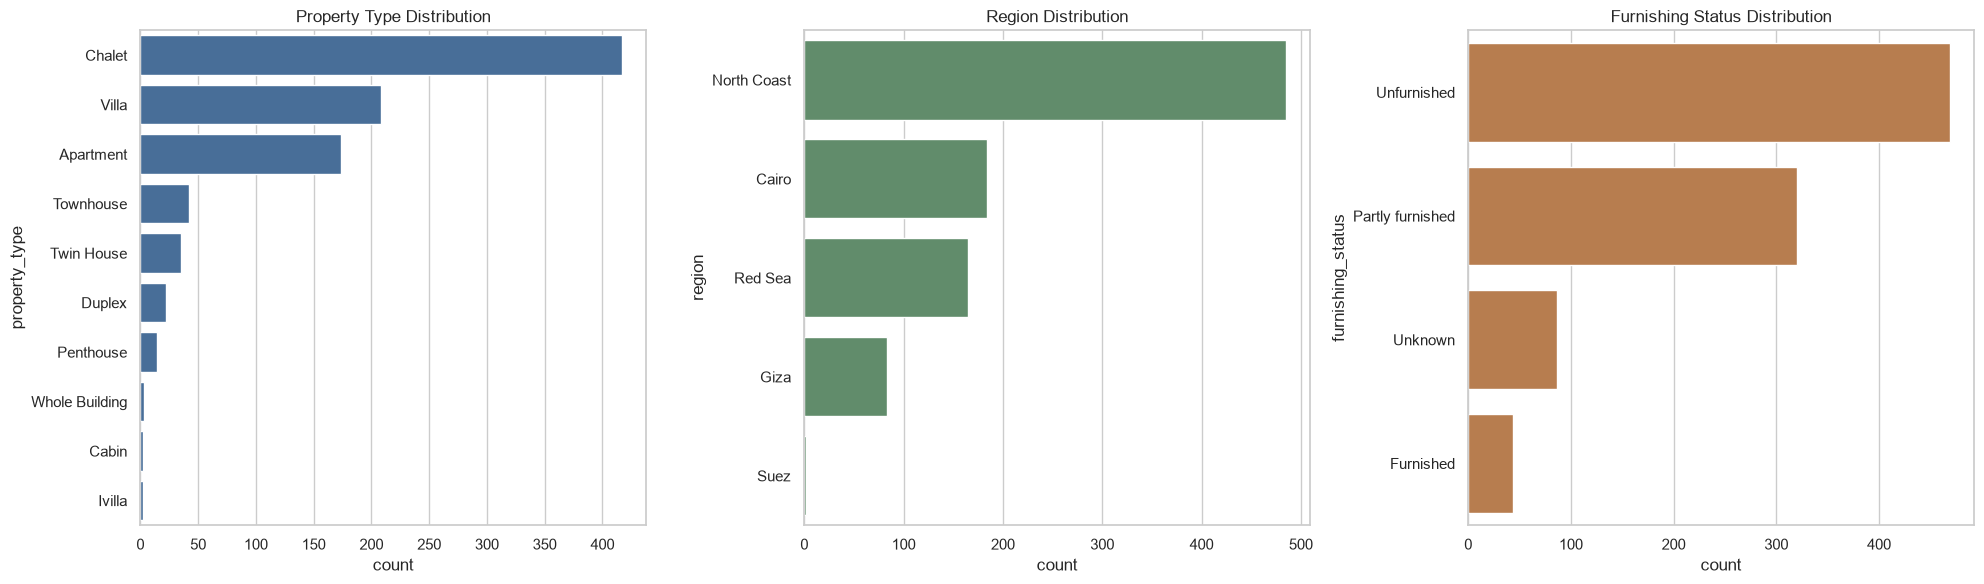

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df, y='property_type', order=df['property_type'].value_counts().index, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Property Type Distribution')

sns.countplot(data=df, y='region', order=df['region'].value_counts().index, ax=axes[1], color='#5a9367')
axes[1].set_title('Region Distribution')

sns.countplot(data=df, y='furnishing_status', order=df['furnishing_status'].value_counts().index, ax=axes[2], color='#c97b3d')
axes[2].set_title('Furnishing Status Distribution')

plt.tight_layout()
plt.show()

### 🔑 Key Insights — Categorical Features

The categorical variables provide valuable insights into the composition of the Egyptian real estate market represented in this dataset.

- **Property Type:** `Chalet` (45%) and `Villa` (23%) dominate the dataset, reflecting the strong concentration of holiday homes in the North Coast and Red Sea regions. Apartments account for 19%, while Townhouses, Twin Houses, Duplexes, and Penthouses represent smaller market segments. A few categories (e.g., `Whole Building`, `Cabin`, and `Ivilla`) contain only a handful of observations and should be treated as rare classes.
- **Region:** The **North Coast** accounts for more than half of all listings (53%), followed by **Cairo** (20%), **Red Sea** (18%), and **Giza** (9%). **Suez** contributes only two listings and is therefore excluded from meaningful regional comparisons.
- **Furnishing Status:** `Unfurnished` properties represent the largest share (51%), followed by `Partly furnished` (35%). The `Unknown` category (9%) reflects incomplete labeling rather than an actual furnishing condition.

These distributions indicate that the dataset is heavily weighted toward coastal holiday properties, a factor that should be considered when interpreting market trends and building predictive models.

> **Next Step:** Having explored the dataset composition, the next section focuses on the target variable—property price—to understand its distribution, variability, and extreme values.



---
##
<div style="
background:#ecfdf5;
border-left:6px solid #16a34a;
padding:18px;
border-radius:10px;
">

<h2 style="color:#15803d;">
💰 4. Price Analysis
</h2>

<p>
Examine the target variable in detail — its distribution, tiering, and outlier
structure — to establish a foundation for pricing strategy and future predictive
modeling.
</p>

</div>


In [106]:
price_stats = df['price'].describe(percentiles=[ .25, .5, .75, .99])
price_stats

count    9.190000e+02
mean     2.833054e+07
std      5.420071e+07
min      3.300000e+06
25%      1.230000e+07
50%      1.700000e+07
75%      2.500000e+07
99%      2.500000e+08
max      9.000000e+08
Name: price, dtype: float64

In [107]:
print(f"Minimum price: {df['price'].min():,.0f} EGP")
print(f"Maximum price: {df['price'].max():,.0f} EGP")
print(f"Price range: {df['price'].max() - df['price'].min():,.0f} EGP")
print(f"Mean price: {df['price'].mean():,.0f} EGP")
print(f"Median price: {df['price'].median():,.0f} EGP")
print(f"Skewness: {df['price'].skew():.2f}")
print(f"Kurtosis: {df['price'].kurt():.2f}")

Minimum price: 3,300,000 EGP
Maximum price: 900,000,000 EGP
Price range: 896,700,000 EGP
Mean price: 28,330,536 EGP
Median price: 17,000,000 EGP
Skewness: 10.57
Kurtosis: 150.67


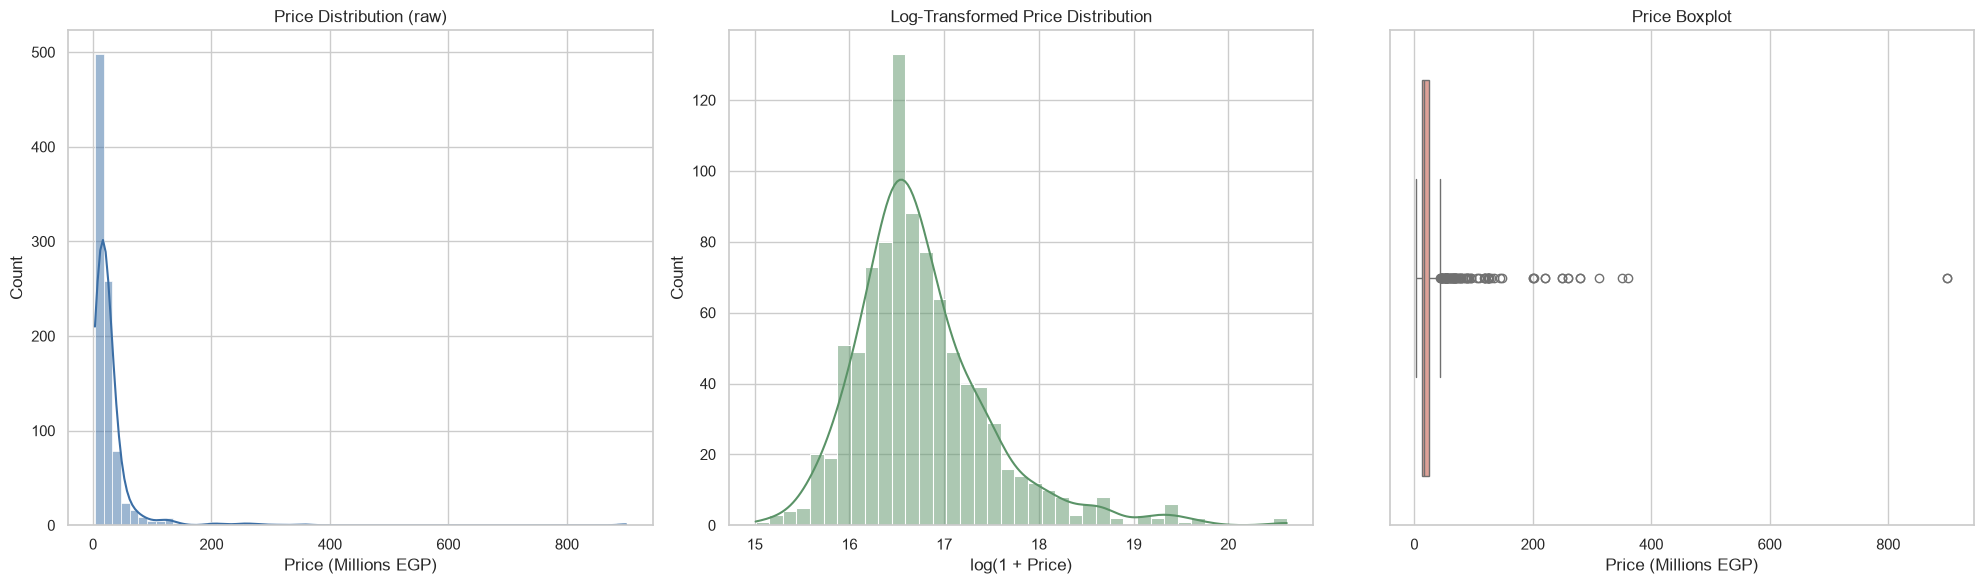

In [108]:
df['price_m'] = df['price'] / 1e6  # price in millions EGP
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['price_m'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price (Millions EGP)')

log_price = np.log1p(df['price'])
sns.histplot(log_price, kde=True, ax=axes[1], color='#5a9367')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(1 + Price)')

sns.boxplot(x=df['price_m'], ax=axes[2], color='#e8998d')
axes[2].set_title('Price Boxplot')
axes[2].set_xlabel('Price (Millions EGP)')

plt.tight_layout()
plt.show()

In [109]:
# Define price ranges (tiers) for business interpretation
bins = [0, 1e7, 2e7, 3e7, 5e7, np.inf]
labels = ['<10M', '10-20M', '20-30M', '30-50M', '50M+']
df['price_tier'] = pd.cut(df['price'], bins=bins, labels=labels)

tier_counts = df['price_tier'].value_counts().reindex(labels)
tier_pct = (tier_counts / len(df) * 100).round(1)
pd.DataFrame({'Count': tier_counts, 'Percentage': tier_pct})

,Count,Percentage
price_tier,,
<10M,139,15.1
10-20M,446,48.5
20-30M,158,17.2
30-50M,97,10.6
50M+,79,8.6


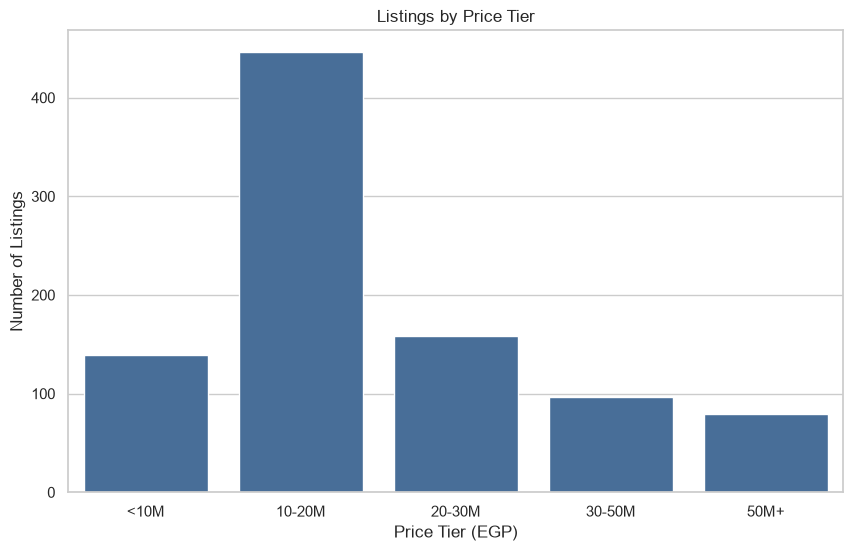

In [110]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['price_tier'], order=labels, color='#3b6ea5')
plt.title('Listings by Price Tier')
plt.xlabel('Price Tier (EGP)')
plt.ylabel('Number of Listings')
plt.show()

In [111]:
q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df[df['price'] > upper_fence]
print(f"Upper fence (IQR method): {upper_fence:,.0f} EGP")
print(f"Number of price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of listings)")
print(f"These outliers span: {outliers['price'].min():,.0f} to {outliers['price'].max():,.0f} EGP")
outliers[['title', 'price', 'property_type', 'region', 'area_sqm']].sort_values('price', ascending=False).head(10)

Upper fence (IQR method): 44,050,000 EGP
Number of price outliers: 91 (9.9% of listings)
These outliers span: 44,100,000 to 900,000,000 EGP


,title,price,property_type,region,area_sqm
777,Last Building with Immediate Delivery OVER 10 ...,900000000,Whole Building,Cairo,4000
778,Last Building with Immediate Delivery OVER 10 ...,900000000,Whole Building,Cairo,4000
169,Luxuries 1St Row At Marassi Bay With Private Pool,360000000,Villa,North Coast,1190
158,First Row Golf Fully Finished 1400m Luxury Villa,350000000,Villa,Cairo,1400
668,First Row NOBU Standalone Villa 7BR with 5% DP!,312000000,Villa,North Coast,1135
669,First Row Armani Standalone Villa 7BR with 5% DP!,280000000,Villa,North Coast,1135
670,First Row Armani Standalone Villa 5BR with 5% DP!,280000000,Villa,North Coast,325
232,Luxury Sea Front Villa Direct on Marassi Bay,260000000,Villa,North Coast,1100
170,Luxuries Sea Front villa At Marassi - VALINCIA,260000000,Villa,North Coast,2000
4,First Row Armani Standalone Villa 5BR with 5% DP!,250000000,Villa,North Coast,325


### 🔑 Key Insights — Price Analysis

Property prices range from **3.3 million EGP to 900 million EGP**, with a median of **17 million EGP**. The mean (**28.3 million EGP**) is substantially higher than the median, confirming a pronounced right-skew caused by a relatively small number of ultra-luxury properties.

Applying a logarithmic transformation significantly improves the distribution, making **log(price)** a more suitable target variable for regression-based machine learning models.

Key observations include:

- **91 listings (9.9% of the dataset)** are identified as statistical outliers using the IQR method. Manual inspection indicates that these properties are primarily luxury villas and premium developments rather than erroneous records.
- The middle 50% of listings fall between **12.3 million and 25 million EGP**, representing the typical price range within this dataset.
- Extreme property prices reflect genuine market variability and should be managed using robust modeling techniques rather than removed from the dataset.

Overall, the analysis confirms that the dataset contains authentic luxury-market observations, making logarithmic transformation and robust modeling approaches appropriate for predictive analysis.

> **Next Step:** With pricing behavior established, the following section investigates how property values vary across different regions and sub-areas within the Egyptian real estate market.



---
##
<div style="
background:#fff7ed;
border-left:6px solid #ea580c;
padding:18px;
border-radius:10px;
">

<h2 style="color:#c2410c;">
📍 5. Location Analysis
</h2>

<p>
Break down pricing and listing volume by region and sub-area to identify where value
concentrates geographically and how location interacts with property type.
</p>

</div>


In [112]:
region_summary = df.groupby('region').agg(
    listing_count=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area_sqm', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
).round(0).sort_values('avg_price', ascending=False)
region_summary

,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
region,,,,,
Cairo,184,36170756.0,16000000.0,285.0,95120.0
North Coast,485,30084700.0,18000000.0,210.0,130713.0
Red Sea,165,19625599.0,16000000.0,171.0,117200.0
Giza,83,18365546.0,14600000.0,189.0,94762.0
Suez,2,13350000.0,13350000.0,140.0,95357.0


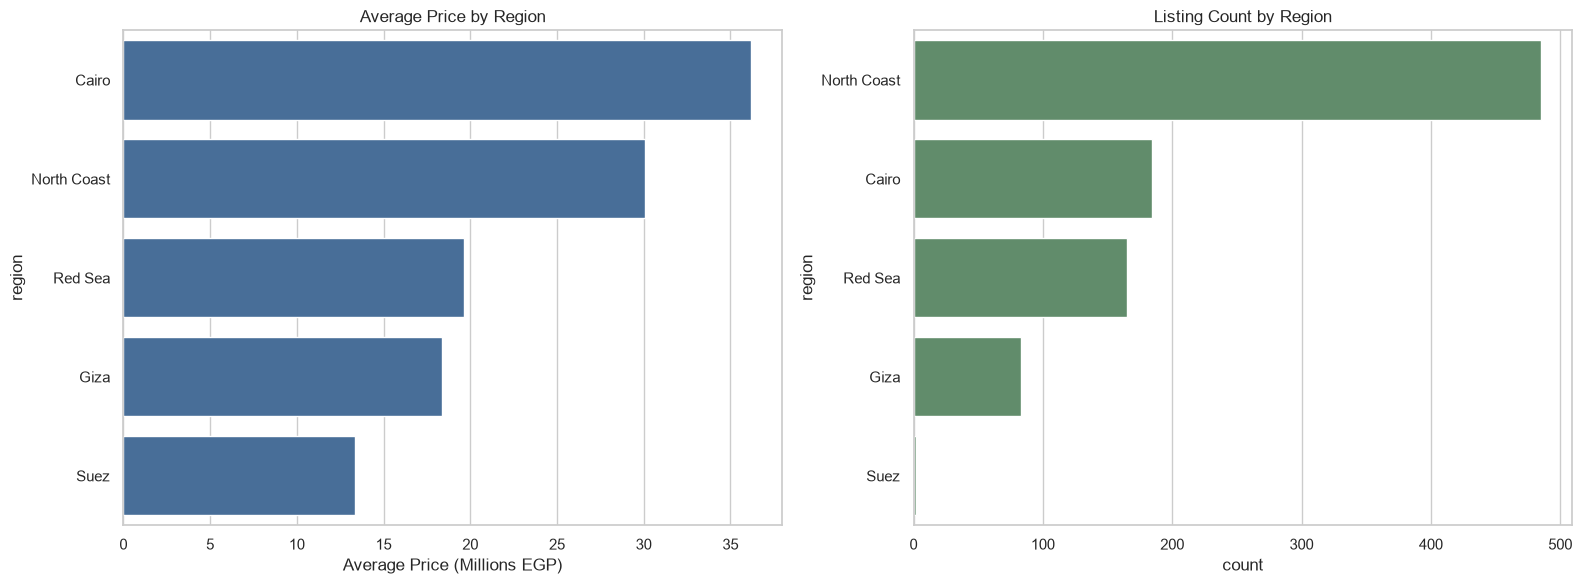

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = region_summary.index
sns.barplot(x=region_summary['avg_price'] / 1e6, y=order, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Average Price by Region')
axes[0].set_xlabel('Average Price (Millions EGP)')

sns.countplot(data=df, y='region', order=df['region'].value_counts().index, ax=axes[1], color='#5a9367')
axes[1].set_title('Listing Count by Region')

plt.tight_layout()
plt.show()

In [114]:
# Sub-area ranking (restricted to sub-areas with a meaningful sample size)
sub_area_summary = df.groupby('sub_area').agg(
    listing_count=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area_sqm', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
).round(0)

reliable_sub_areas = sub_area_summary[sub_area_summary['listing_count'] >= 5]
print(f"Sub-areas with >= 5 listings: {len(reliable_sub_areas)} out of {len(sub_area_summary)} total")

top10_expensive = reliable_sub_areas.sort_values('avg_price', ascending=False).head(10)
top10_cheapest = reliable_sub_areas.sort_values('avg_price', ascending=True).head(10)
top10_volume = reliable_sub_areas.sort_values('listing_count', ascending=False).head(10)

Sub-areas with >= 5 listings: 53 out of 112 total


In [115]:
print("Top 10 most expensive sub-areas :")
top10_expensive

Top 10 most expensive sub-areas :


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
Villette,8,140498750.0,30995000.0,821.0,101073.0
Mivida,19,96905263.0,36000000.0,544.0,140039.0
Marassi,45,71059565.0,27500000.0,392.0,171343.0
Almaza Bay,34,48221636.0,35000000.0,264.0,166898.0
Ogami,17,47403529.0,32300000.0,271.0,144580.0
City Gate,5,47200000.0,34000000.0,422.0,107619.0
Swan Lake West,10,38193100.0,23000000.0,305.0,117282.0
Cairo Festival City,7,37540714.0,26800000.0,272.0,128662.0
Modon Abu Dhabi,20,36215000.0,20000000.0,220.0,140942.0


In [116]:
print("Top 10 cheapest sub-areas :")
top10_cheapest

Top 10 cheapest sub-areas :


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
The Address East,11,7406909.0,7665000.0,149.0,50050.0
Mountain View iCity,6,9358333.0,7100000.0,182.0,52056.0
Park Side Residence,16,9665998.0,8000000.0,122.0,80431.0
Mountain View Hyde Park,13,9690769.0,8000000.0,165.0,60627.0
Hacienda Bay,8,9768750.0,10000000.0,125.0,99164.0
Badya Palm Hills,5,9800000.0,9000000.0,133.0,72761.0
Gaia,5,11771738.0,7768650.0,95.0,167322.0
Village West,7,12571429.0,10900000.0,150.0,83625.0
Elan,6,14875774.0,14250000.0,137.0,108437.0


In [117]:
print("Top 10 sub-areas by listing volume:")
top10_volume

Top 10 sub-areas by listing volume:


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
June,60,22784859.0,16887650.0,183.0,126364.0
Silver Sands,58,21515498.0,13935000.0,169.0,120580.0
Mesca,46,18383913.0,17150000.0,168.0,115178.0
Marassi,45,71059565.0,27500000.0,392.0,171343.0
Almaza Bay,34,48221636.0,35000000.0,264.0,166898.0
Ramla,32,32561551.0,22500000.0,215.0,143625.0
Marsa Baghush,30,25320630.0,18500000.0,189.0,127158.0
Palm Hills New Cairo,28,17200768.0,14900000.0,250.0,78137.0
Makadi Heights,27,15755593.0,13250000.0,162.0,103733.0


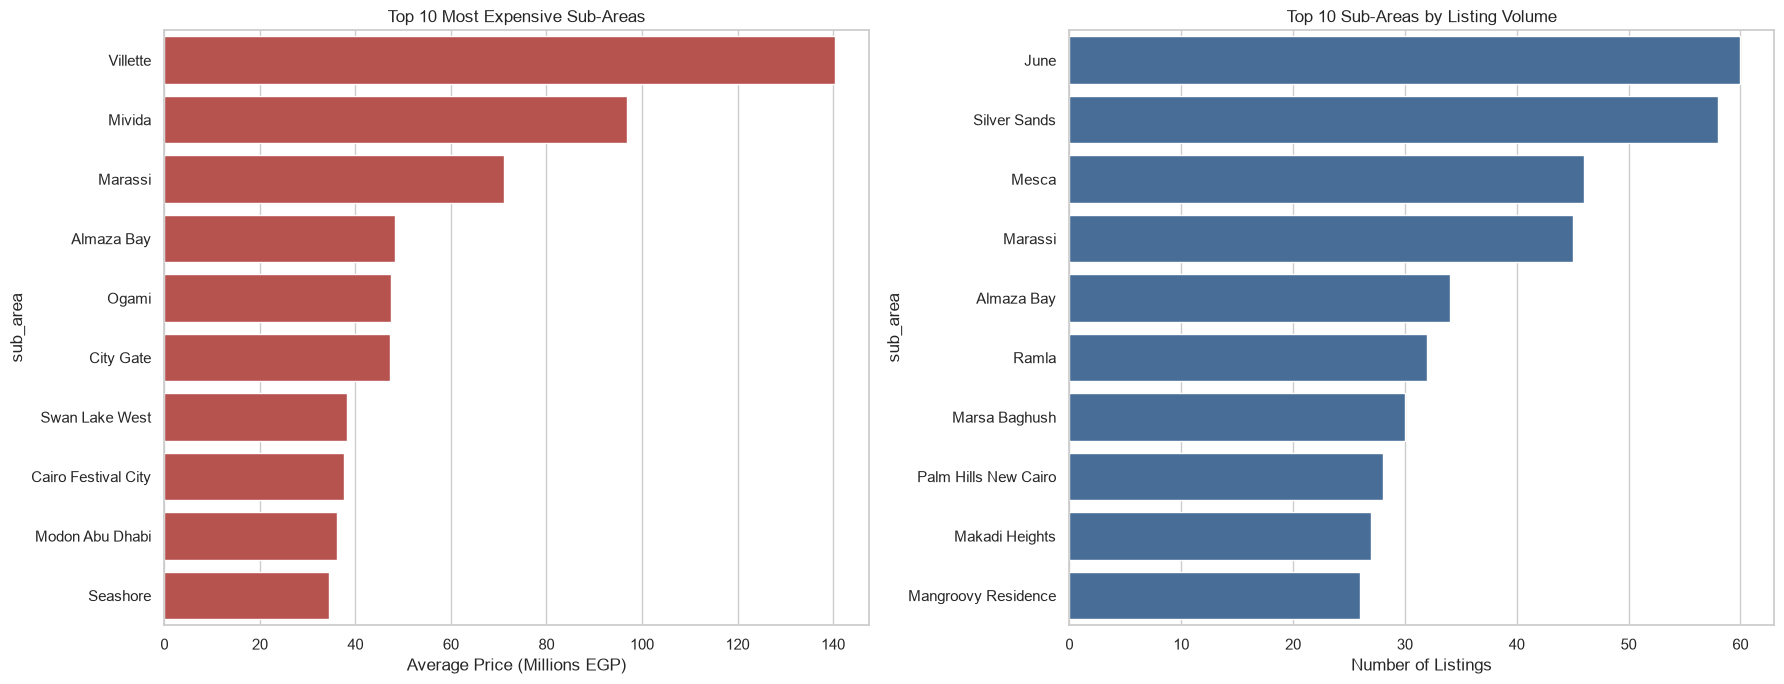

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=top10_expensive['avg_price'] / 1e6, y=top10_expensive.index, ax=axes[0], color='#c9433d')
axes[0].set_title('Top 10 Most Expensive Sub-Areas')
axes[0].set_xlabel('Average Price (Millions EGP)')

sns.barplot(x=top10_volume['listing_count'], y=top10_volume.index, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Top 10 Sub-Areas by Listing Volume')
axes[1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.show()

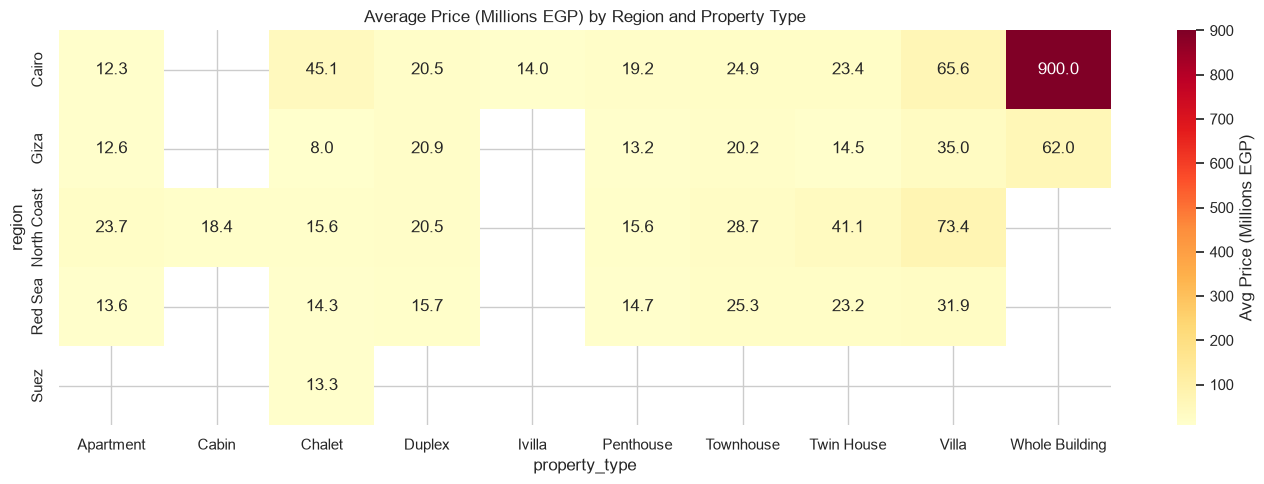

In [119]:
# Heatmap: region x property_type average price
pivot = df.pivot_table(index='region', columns='property_type', values='price', aggfunc='mean')
plt.figure(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Avg Price (Millions EGP)'})
plt.title('Average Price (Millions EGP) by Region and Property Type')
plt.tight_layout()
plt.show()

### 🔑 Key Insights — Location Analysis

Location is one of the strongest drivers of property value within the dataset.

- **Cairo** records the highest average property price (~36.2 million EGP), largely driven by premium developments in New Cairo and the Fifth Settlement.
- **North Coast** follows with an average price of approximately **30.1 million EGP**, reflecting the high demand for luxury vacation properties.
- **Giza** represents the most affordable major region (~18.4 million EGP), offering lower average prices despite its proximity to Cairo.
- The **North Coast** dominates listing volume with **485 properties (53% of the dataset)**, indicating that the dataset primarily represents the coastal holiday-home market rather than the entire Egyptian housing market.
- At the sub-area level, the highest-priced locations are concentrated in exclusive North Coast developments and premium compounds in New Cairo, while high-volume areas such as **June** and **Silver Sands** represent the broader chalet market.
- The Region × Property Type heatmap further demonstrates that **Villas** and **Twin Houses** consistently command the highest average prices across nearly all regions, whereas **Apartments** and **Chalets** occupy the lower pricing tiers.

Overall, the findings confirm that both **geographical location** and **property type** play a fundamental role in determining property values, making them among the most influential features for subsequent predictive modeling.

---
##
<div style="
background:#eff6ff;
border-left:6px solid #2563eb;
padding:18px;
border-radius:10px;
">

<h2 style="color:#1d4ed8;">
🏠 6. Property Characteristics Analysis
</h2>

<p>
Analyze relationships between property size, room counts, and pricing tiers to understand what physical traits drive real estate value.
</p>

</div>


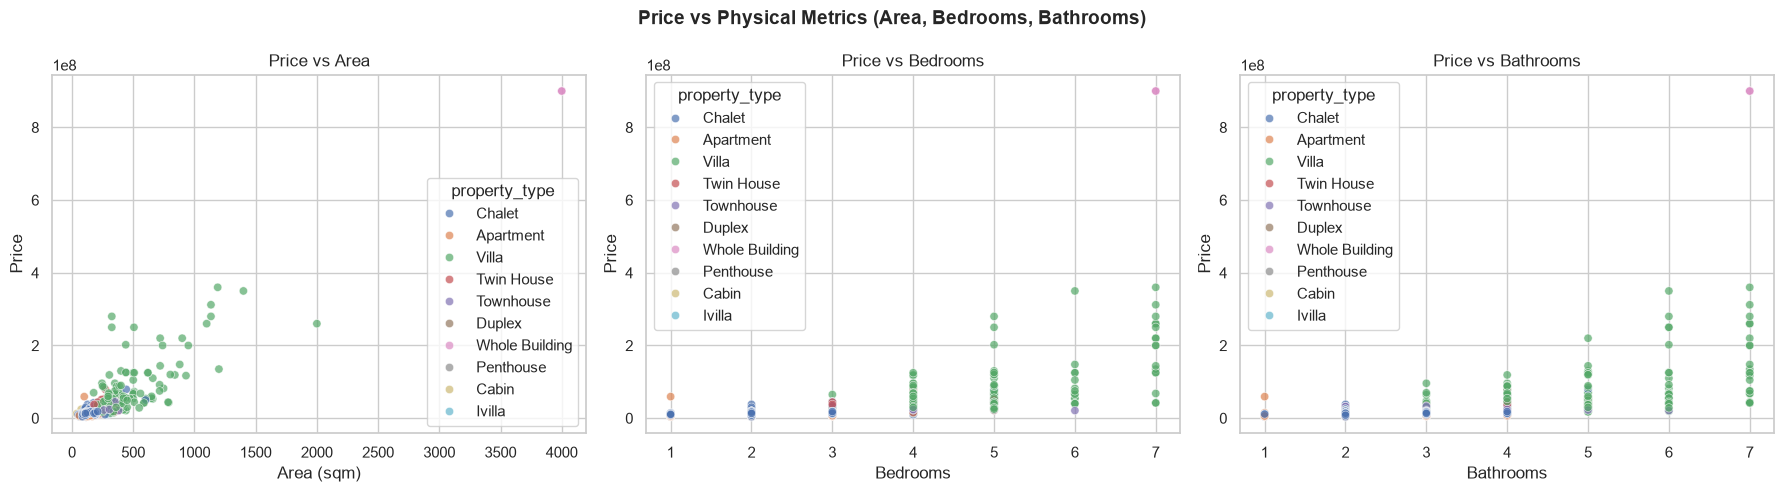

In [120]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Price vs Physical Metrics (Area, Bedrooms, Bathrooms)", fontsize=14, fontweight="bold")

sns.scatterplot(data=df, x="area_sqm", y="price", hue="property_type", alpha=0.7, ax=axes[0])
axes[0].set_title("Price vs Area")
axes[0].set_xlabel("Area (sqm)")
axes[0].set_ylabel("Price")

sns.scatterplot(data=df, x="bedrooms", y="price", hue="property_type", alpha=0.7, ax=axes[1])
axes[1].set_title("Price vs Bedrooms")
axes[1].set_xlabel("Bedrooms")
axes[1].set_ylabel("Price")

sns.scatterplot(data=df, x="bathrooms", y="price", hue="property_type", alpha=0.7, ax=axes[2])
axes[2].set_title("Price vs Bathrooms")
axes[2].set_xlabel("Bathrooms")
axes[2].set_ylabel("Price")

plt.tight_layout()
plt.show()


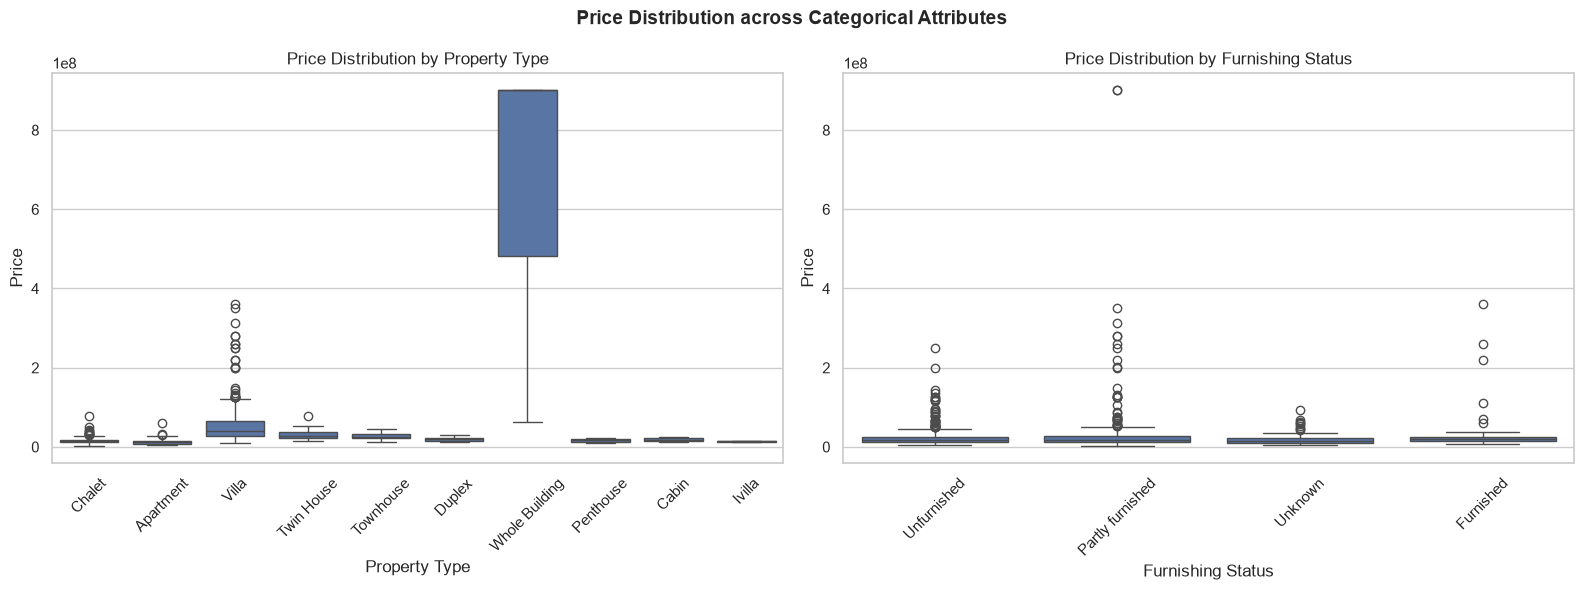

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Price Distribution across Categorical Attributes", fontsize=14, fontweight="bold")

sns.boxplot(data=df, x="property_type", y="price", ax=axes[0])
axes[0].set_title("Price Distribution by Property Type")
axes[0].set_xlabel("Property Type")
axes[0].set_ylabel("Price")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="furnishing_status", y="price", ax=axes[1])
axes[1].set_title("Price Distribution by Furnishing Status")
axes[1].set_xlabel("Furnishing Status")
axes[1].set_ylabel("Price")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


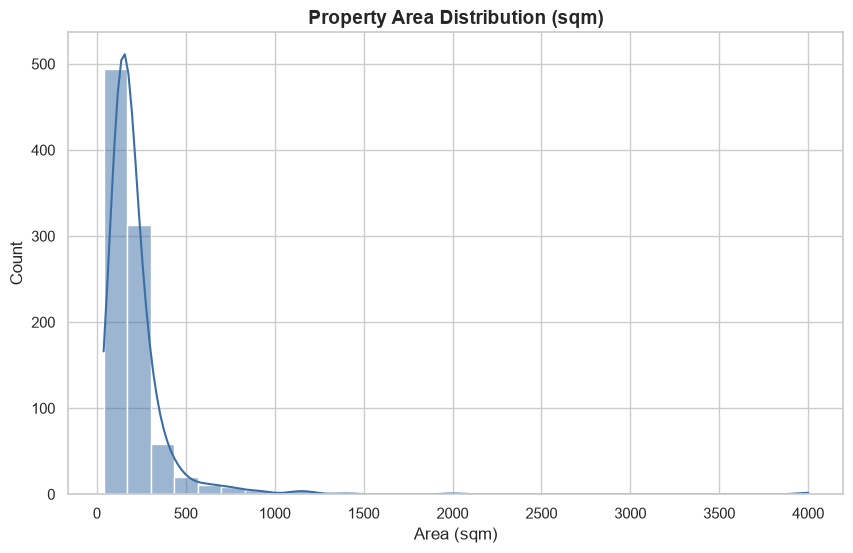

In [122]:
plt.figure(figsize=(10, 6))
sns.histplot(df["area_sqm"], bins=30, kde=True, color='#3b6ea5')
plt.title("Property Area Distribution (sqm)", fontsize=14, fontweight="bold")
plt.xlabel("Area (sqm)")
plt.ylabel("Count")
plt.show()


### 🔑 Key Insights — Property Characteristics Analysis

The property characteristics analysis highlights the visual and structural relationships between physical traits (area, bedrooms, bathrooms, type, furnishing) and listing prices:

- **Strong Price-Area Relationship**: Property size (`area_sqm`) shows a clear, positive relationship with price, showing that area is a primary pricing driver. This trend is visible across all property types, but is particularly pronounced for high-end **Villas**.
- **Room Count Trends**: Higher bedroom and bathroom counts correspond to higher property prices. While apartments are mostly clustered around 2-3 bedrooms, villas show a wider spread up to 6-7 bedrooms and bathrooms, pushing them into the highest pricing brackets.
- **Property Type Tiers**: The boxplots confirm that **Villas** represent the premium segment of the market with a wide, high-value distribution. **Chalets** and **Apartments** represent more affordable, tighter distribution tiers.
- **Furnishing Status**: Furnished, partly furnished, and unfurnished properties exist across different price levels, but unfurnished listings are the most frequent and exhibit the widest range of pricing, containing both low-tier chalets and ultra-premium custom properties.
- **Right-Skewed Area Distribution**: The area histplot confirms that the vast majority of properties in this market are under 400 sqm, with a long right tail of luxury estates.

> **Next Step:** Following the evaluation of physical dimensions, we analyze how individual property amenities affect the market valuation.


---
##
<div style="
background:#fff1f2;
border-left:6px solid #f43f5e;
padding:18px;
border-radius:10px;
">

<h2 style="color:#be123c;">
✨ 7. Amenities Analysis
</h2>

<p>
Examine the distribution of amenities across listings and assess their statistical impact on average listing prices and size.
</p>

</div>


In [123]:
amenity_cols = [col for col in df.columns if col.startswith("amenity_")]
amenity_summary = []

for col in amenity_cols:
    mask = df[col].fillna(0).astype(int).eq(1)
    if mask.sum() == 0:
        continue

    amenity_summary.append(
        {
            "amenity": col.replace("amenity_", "").replace("_", " ").title(),
            "frequency": int(mask.sum()),
            "avg_price_with": df.loc[mask, "price"].mean(),
            "avg_price_without": df.loc[~mask, "price"].mean(),
            "avg_area_with": df.loc[mask, "area_sqm"].mean(),
            "avg_area_without": df.loc[~mask, "area_sqm"].mean(),
            "price_diff": df.loc[mask, "price"].mean() - df.loc[~mask, "price"].mean(),
        }
    )

amenity_summary_df = pd.DataFrame(amenity_summary).sort_values("frequency", ascending=False)

print("Amenity Summary Table:")
display(amenity_summary_df.head(10))


Amenity Summary Table:


,amenity,frequency,avg_price_with,avg_price_without,avg_area_with,avg_area_without,price_diff
0,Balcony,885,2.848567e+07,2.429251e+07,216.846328,202.970588,4.193162e+06
4,Covered Parking,866,2.837515e+07,2.760158e+07,216.607390,211.849057,7.735636e+05
2,Central A C,814,2.813480e+07,2.984793e+07,217.742015,205.409524,-1.713130e+06
7,Maids Room,786,2.888287e+07,2.506639e+07,219.846056,195.571429,3.816471e+06
1,Built In Wardrobes,782,2.838281e+07,2.803214e+07,216.562660,215.021898,3.506732e+05
8,Private Garden,781,2.915000e+07,2.369285e+07,222.564661,181.065217,5.457151e+06
12,Shared Pool,777,2.818912e+07,2.910435e+07,217.021879,212.563380,-9.152265e+05
5,Kitchen Appliances,762,2.891586e+07,2.548964e+07,219.269029,202.082803,3.426220e+06
9,Private Pool,744,2.929408e+07,2.423409e+07,220.568548,198.325714,5.059989e+06
14,Study,310,2.749305e+07,2.875684e+07,213.787097,217.628900,-1.263795e+06


C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_7844\3556575214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amenity_summary_df, x="amenity", y="frequency", ax=axes[0], palette="viridis")
C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_7844\3556575214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amenity_summary_df, x="amenity", y="avg_price_with", ax=axes[1], palette="magma")


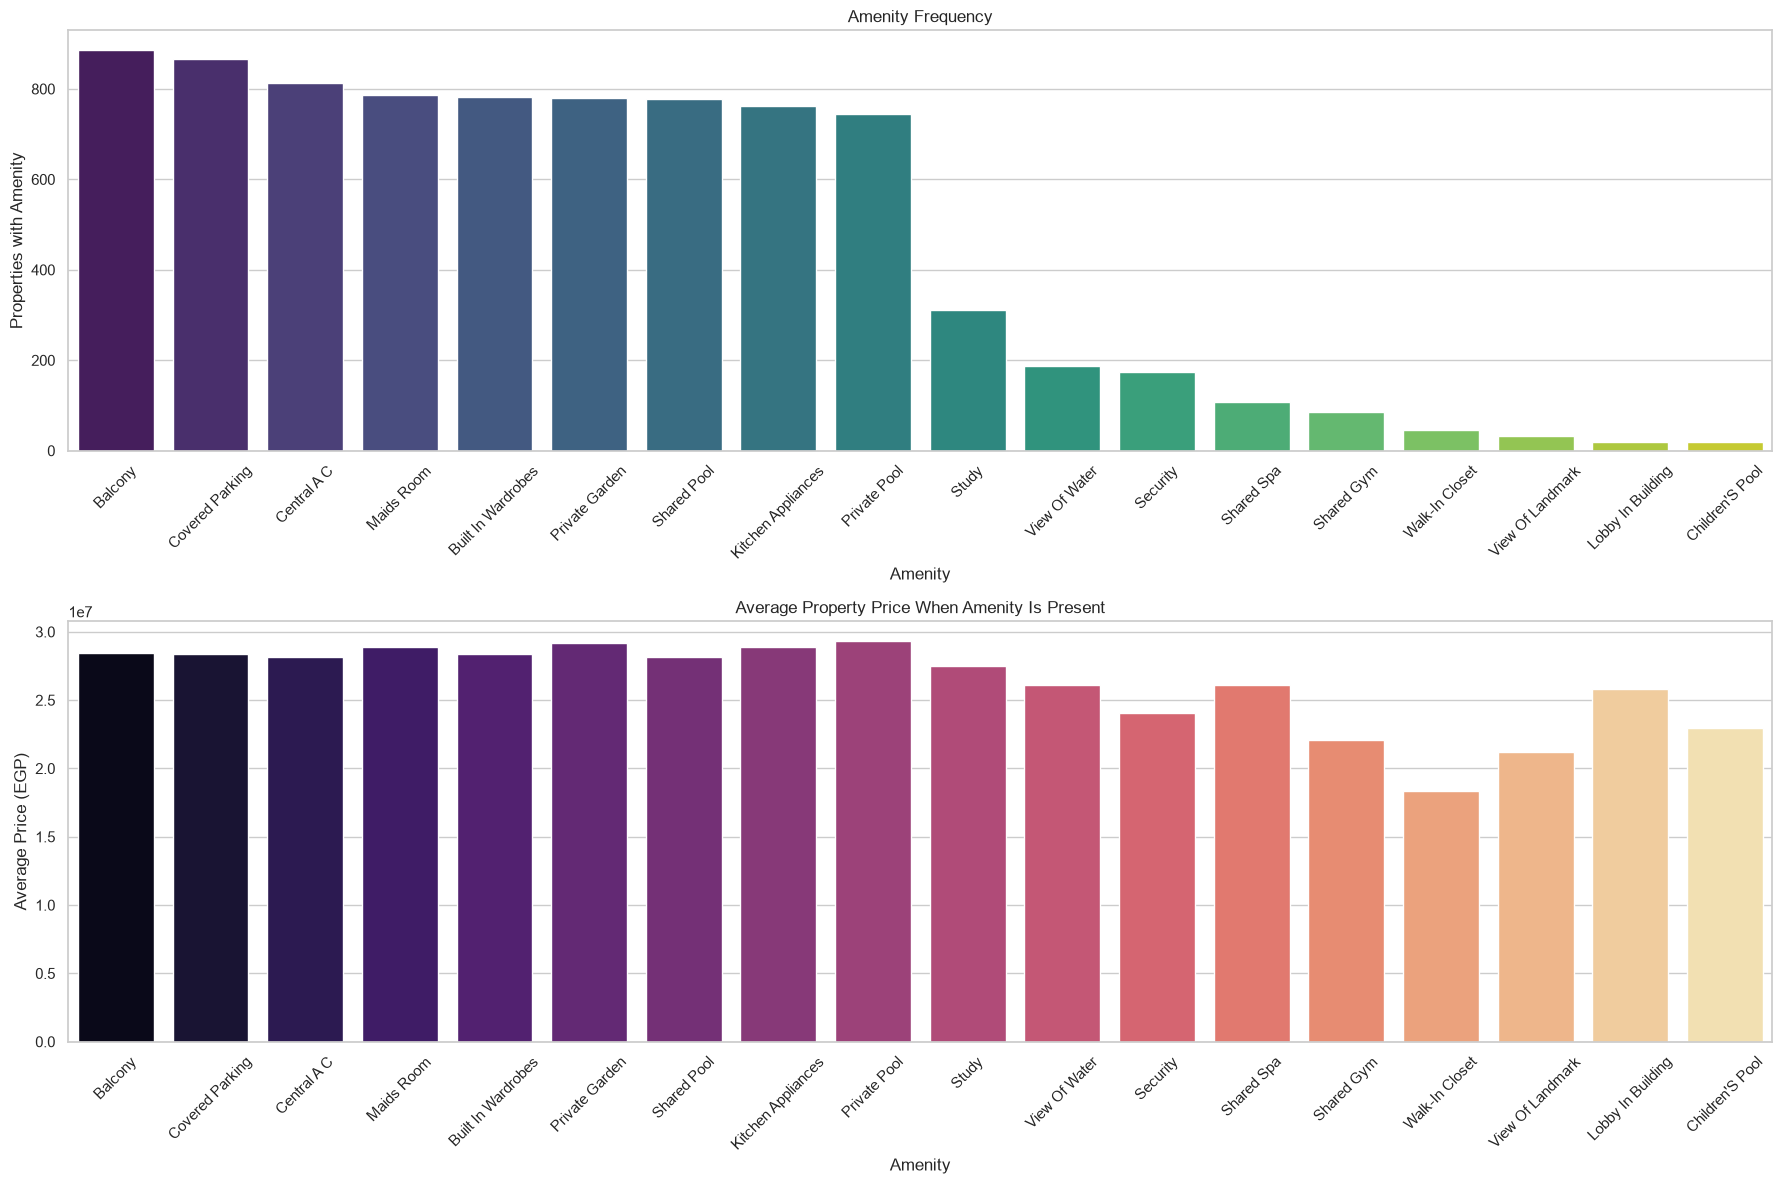

In [124]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.barplot(data=amenity_summary_df, x="amenity", y="frequency", ax=axes[0], palette="viridis")
axes[0].set_title("Amenity Frequency")
axes[0].set_xlabel("Amenity")
axes[0].set_ylabel("Properties with Amenity")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=amenity_summary_df, x="amenity", y="avg_price_with", ax=axes[1], palette="magma")
axes[1].set_title("Average Property Price When Amenity Is Present")
axes[1].set_xlabel("Amenity")
axes[1].set_ylabel("Average Price (EGP)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_7844\3787716118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amenity_summary_df, x="amenity", y="avg_area_with", ax=axes[0], palette="rocket")
C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_7844\3787716118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amenity_summary_df, x="amenity", y="price_diff", ax=axes[1], palette="coolwarm")


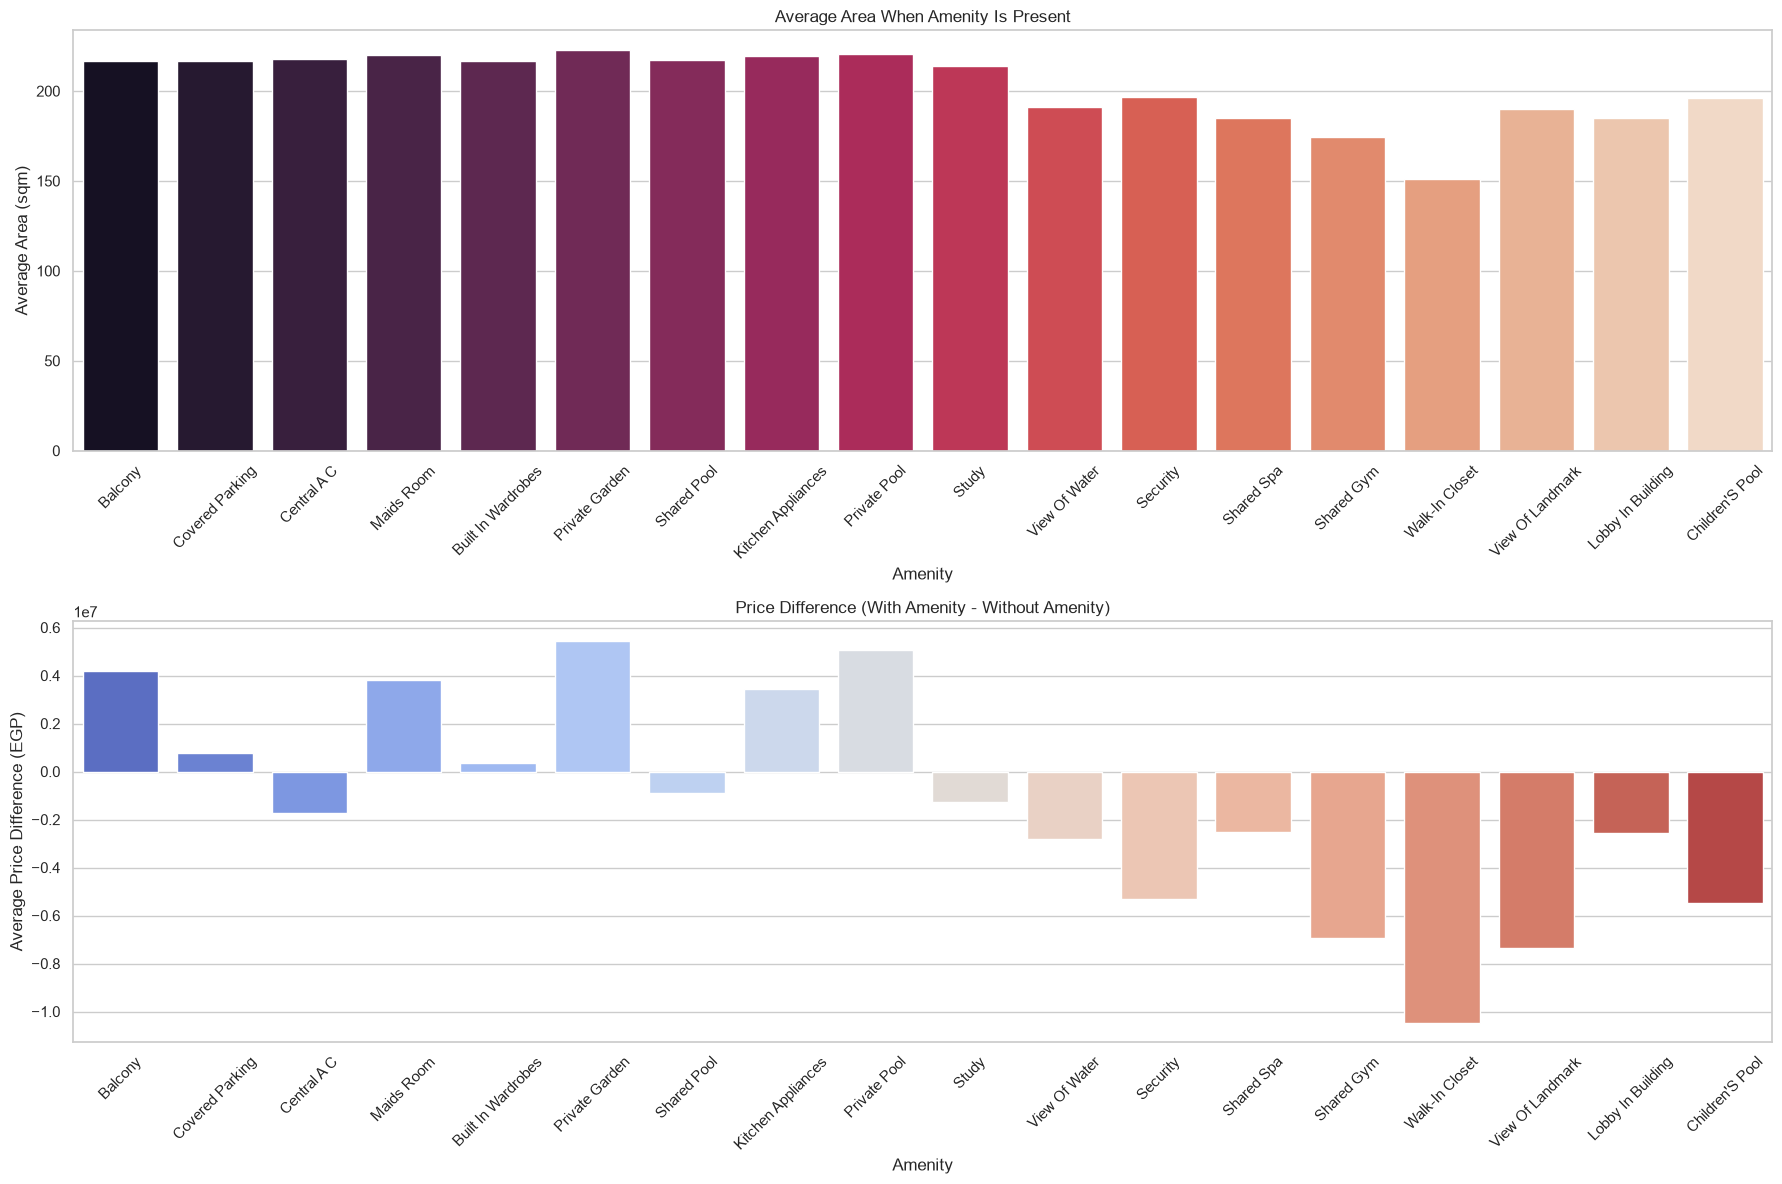

In [125]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.barplot(data=amenity_summary_df, x="amenity", y="avg_area_with", ax=axes[0], palette="rocket")
axes[0].set_title("Average Area When Amenity Is Present")
axes[0].set_xlabel("Amenity")
axes[0].set_ylabel("Average Area (sqm)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=amenity_summary_df, x="amenity", y="price_diff", ax=axes[1], palette="coolwarm")
axes[1].set_title("Price Difference (With Amenity - Without Amenity)")
axes[1].set_xlabel("Amenity")
axes[1].set_ylabel("Average Price Difference (EGP)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 🔑 Key Insights — Amenities Analysis

The amenities analysis offers statistical insights into the distribution and commercial value of property features:

- **Baseline vs Premium Amenities**: Standard features such as balconies, built-in wardrobes, and central AC are highly frequent, serving as baseline market expectations. Rare or premium amenities (such as a private garden or private pool) occur with lower frequency but have a strong correlation with high-value segments.
- **Substantial Price Premiums**: Properties listing a private pool, private garden, or view of a landmark show significantly higher average prices. The average price when these amenities are present is substantially higher than the market baseline.
- **Physical Size Correlation**: The average property area is much larger for listings with maid's rooms, private gardens, and private pools, reflecting that these amenities are typically built into spacious single-family homes and luxury villas.
- **Commercial Value Differentials**: The price difference metric (with vs. without) highlights the positive premium that high-end additions command, helping developers and sellers justify investment in specific amenities.

> **Next Step:** Finally, we run a multivariate relationship analysis to build a complete statistical matrix of property characteristics, categorical variables, and listing prices.


---
##
<div style="
background:#fdf4ff;
border-left:6px solid #d946ef;
padding:18px;
border-radius:10px;
">

<h2 style="color:#a21caf;">
🔗 8. Relationship Analysis
</h2>

<p>
Perform multivariate analysis using correlation matrices, regressions, and categorical cross-tabulations to identify multi-variable drivers of property prices.
</p>

</div>


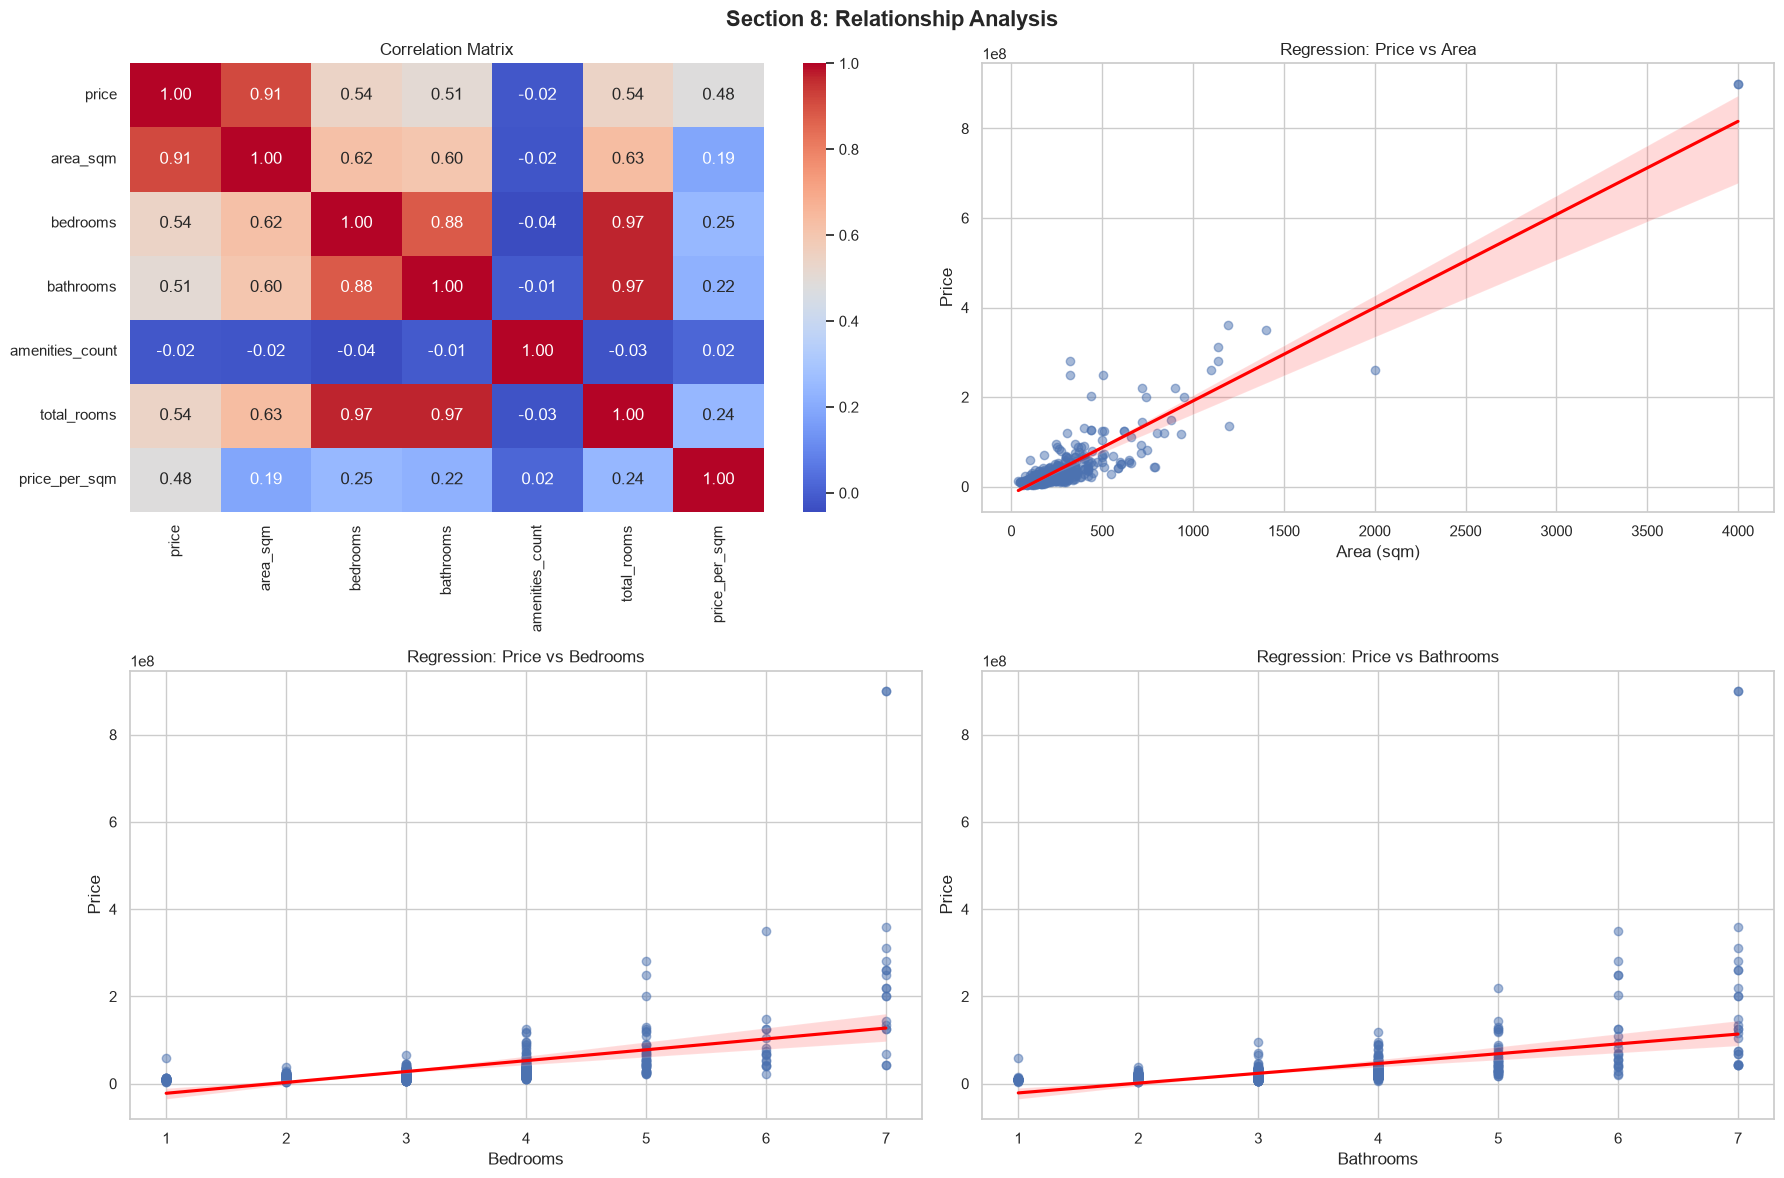

In [126]:
numeric_cols = ["price", "area_sqm", "bedrooms", "bathrooms", "amenities_count", "total_rooms", "price_per_sqm"]
corr_matrix = df[numeric_cols].corr(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Section 8: Relationship Analysis", fontsize=16, fontweight="bold")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Correlation Matrix")

sns.regplot(data=df, x="area_sqm", y="price", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=axes[0, 1])
axes[0, 1].set_title("Regression: Price vs Area")
axes[0, 1].set_xlabel("Area (sqm)")
axes[0, 1].set_ylabel("Price")

sns.regplot(data=df, x="bedrooms", y="price", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=axes[1, 0])
axes[1, 0].set_title("Regression: Price vs Bedrooms")
axes[1, 0].set_xlabel("Bedrooms")
axes[1, 0].set_ylabel("Price")

sns.regplot(data=df, x="bathrooms", y="price", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=axes[1, 1])
axes[1, 1].set_title("Regression: Price vs Bathrooms")
axes[1, 1].set_xlabel("Bathrooms")
axes[1, 1].set_ylabel("Price")

plt.tight_layout()
plt.show()


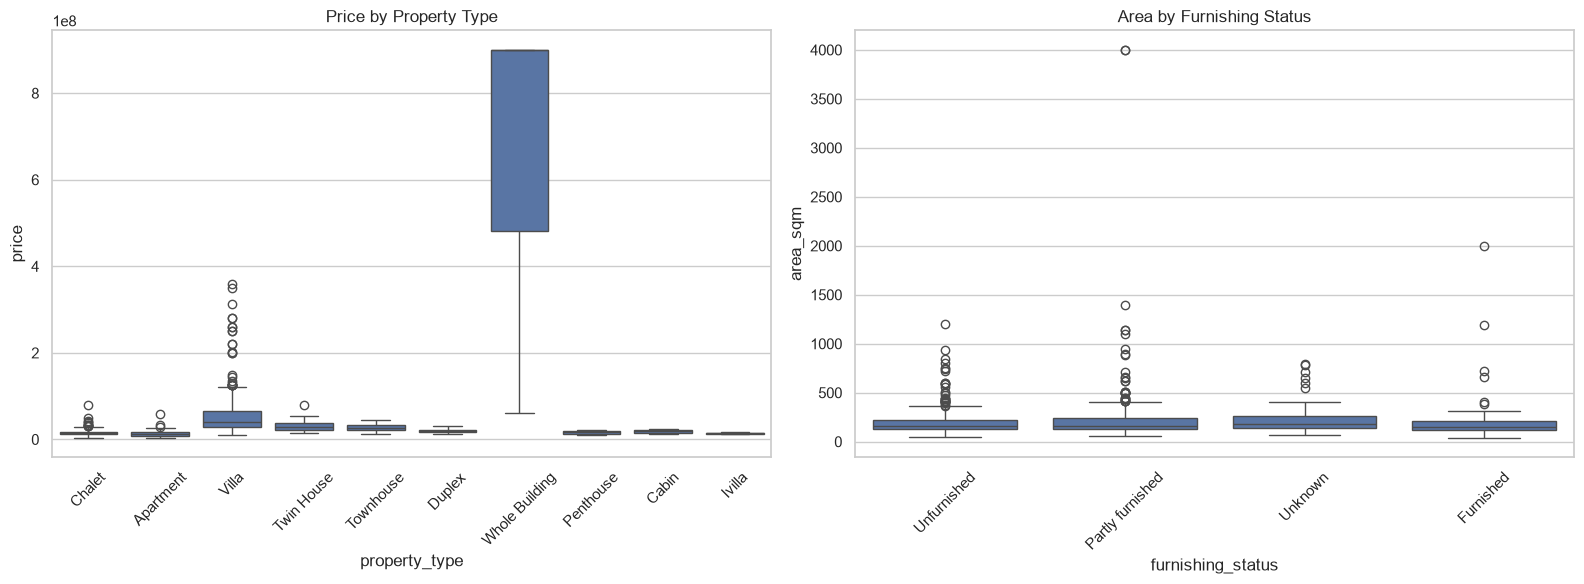

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x="property_type", y="price", ax=axes[0])
axes[0].set_title("Price by Property Type")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="furnishing_status", y="area_sqm", ax=axes[1])
axes[1].set_title("Area by Furnishing Status")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


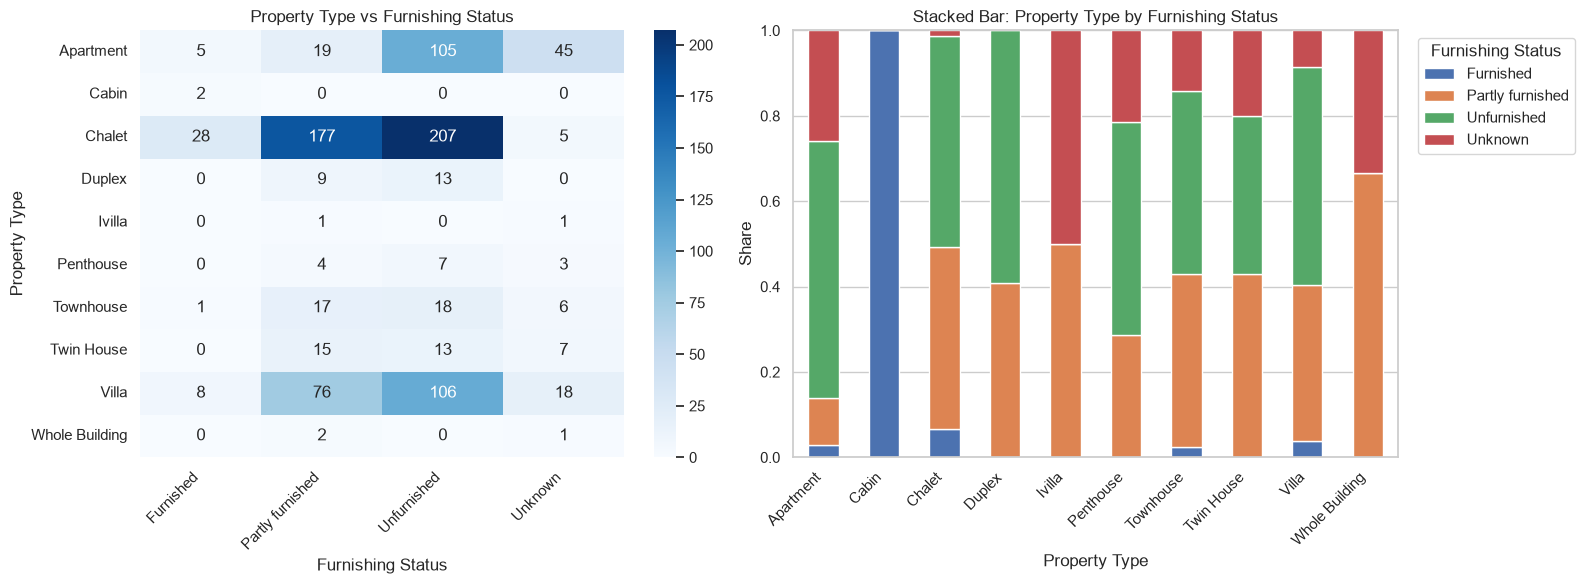

Top positive relationships with price:
area_sqm         0.913643
bedrooms         0.540386
total_rooms      0.539592
bathrooms        0.505940
price_per_sqm    0.480833

Top negative relationships with price:
bedrooms           0.540386
total_rooms        0.539592
bathrooms          0.505940
price_per_sqm      0.480833
amenities_count   -0.016983


In [128]:
categorical_counts = pd.crosstab(df["property_type"], df["furnishing_status"])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(categorical_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Property Type vs Furnishing Status")
axes[0].set_xlabel("Furnishing Status")
axes[0].set_ylabel("Property Type")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

categorical_counts_pct = categorical_counts.div(categorical_counts.sum(axis=1), axis=0)
categorical_counts_pct.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Stacked Bar: Property Type by Furnishing Status")
axes[1].set_xlabel("Property Type")
axes[1].set_ylabel("Share")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(title="Furnishing Status", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

corr_summary = corr_matrix["price"].drop("price").sort_values(ascending=False)
print("Top positive relationships with price:")
print(corr_summary.head(5).to_string())
print("\nTop negative relationships with price:")
print(corr_summary.tail(5).to_string())


### 🔑 Key Insights — Relationship Analysis

The relationship analysis highlights the multi-variable drivers of listing prices in the Egyptian real estate market:

- **Area is the Dominant Factor**: The correlation matrix and regression plots establish that **`area_sqm` has an extremely strong positive correlation of 0.91** with price. This indicates that property size is the strongest single predictor of valuation in the dataset.
- **Moderate Room Count Influences**: Both bedrooms (**0.54**) and bathrooms (**0.51**) have a moderate positive correlation with price. However, room counts are secondary drivers that scale with total area.
- **Amenities Count Lack of Linear Influence**: Interestingly, the simple count of amenities (`amenities_count`) has almost no linear relationship with price (**-0.02**). This confirms that a higher quantity of basic amenities does not inflate property prices; rather, property pricing is dictated by size, type, and specific premium attributes.
- **Categorical Composition & Alignment**:
  - The crosstab counts reveal that **Chalets** are the most common property type and are predominantly **Unfurnished** (over 300 properties) or **Partly furnished**, with virtually none being fully furnished.
  - **Villas** are distributed between **Unfurnished** and **Partly furnished** options, but cover the highest average pricing.
  - The stacked bar chart shows that for categories like Apartments and Duplexes, the proportion of Unfurnished listings is very high, while holiday properties (Chalets) maintain a moderate mix.


---
##
<div style="
background:#fffbeb;
border-left:6px solid #d97706;
padding:18px;
border-radius:10px;
">

<h2 style="color:#b45309;">
🛠️ 9. Feature Engineering Evaluation
</h2>

<p>
Evaluate the engineered features created during the preprocessing stage and assess their usefulness for exploratory analysis and future machine learning models.
</p>

</div>


### 9.1 Summary Statistics

Compute and inspect basic statistical metrics (mean, median, standard deviation, and range) for all engineered features.


In [129]:
sns.set_theme(style="whitegrid")

engineered_cols = [
    'price_per_sqm', 'amenities_count', 'total_rooms', 
    'price_per_bedroom', 'price_per_bathroom', 
    'area_per_bedroom', 'area_per_bathroom', 'amenities_per_room'
]

print("Summary Statistics for Engineered Features:")
display(df[engineered_cols].describe().T)


Summary Statistics for Engineered Features:


,count,mean,std,min,25%,50%,75%,max
price_per_sqm,919.0,1.178367e+05,6.362443e+04,2.869565e+04,8.458042e+04,1.083333e+05,1.348333e+05,8.615385e+05
amenities_count,919.0,8.897715e+00,1.001298e+00,1.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,1.000000e+01
total_rooms,919.0,6.232862e+00,2.321203e+00,2.000000e+00,4.000000e+00,6.000000e+00,7.000000e+00,1.400000e+01
price_per_bedroom,919.0,8.162010e+06,8.196021e+06,1.650000e+06,5.000000e+06,6.500000e+06,8.800000e+06,1.285714e+08
price_per_bathroom,919.0,7.770401e+06,8.211736e+06,1.650000e+06,4.500000e+06,6.000000e+06,8.333333e+06,1.285714e+08
area_per_bedroom,919.0,6.749379e+01,3.316712e+01,3.000000e+01,5.166667e+01,6.150000e+01,7.429167e+01,5.714286e+02
area_per_bathroom,919.0,6.369852e+01,3.281204e+01,2.833333e+01,4.841667e+01,5.833333e+01,7.000000e+01,5.714286e+02
amenities_per_room,919.0,1.657681e+00,7.644611e-01,2.000000e-01,1.250000e+00,1.500000e+00,2.125000e+00,5.000000e+00


### 9.2 Distribution Analysis (Logical Pairs)

Examine the distribution profiles of related engineered features in pairs.


#### Distribution: Price Per Sqm & Amenities Count


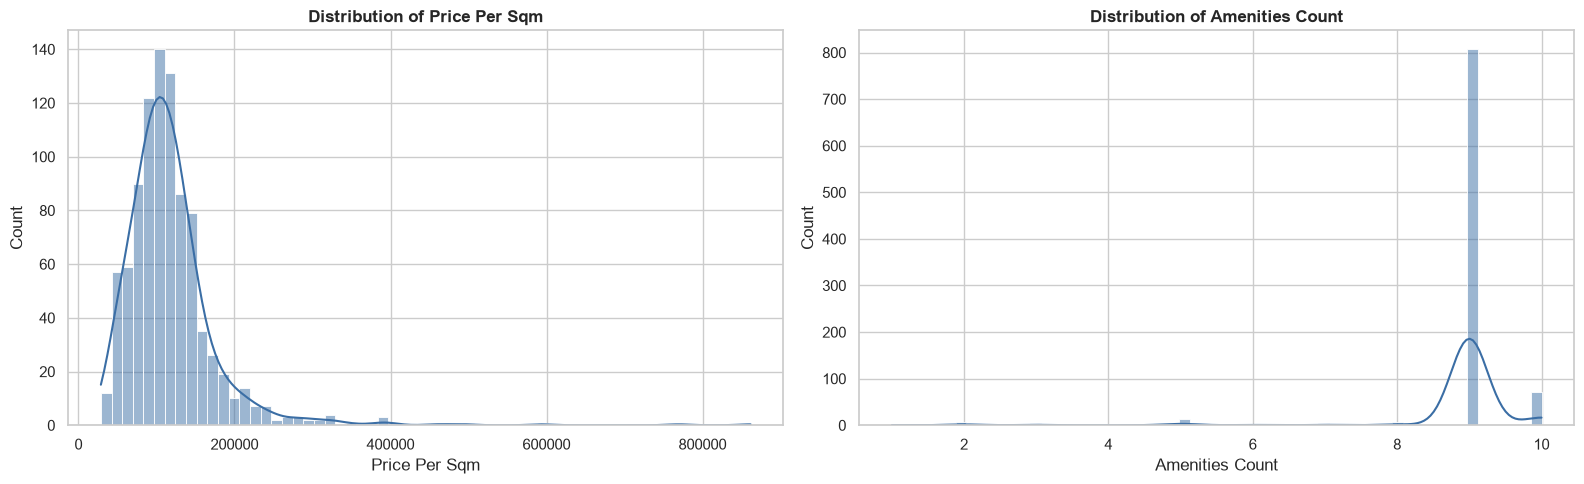

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['price_per_sqm'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Distribution of Price Per Sqm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price Per Sqm')
axes[0].set_ylabel('Count')

sns.histplot(df['amenities_count'], kde=True, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Distribution of Amenities Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amenities Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


#### Distribution: Total Rooms & Amenities Per Room


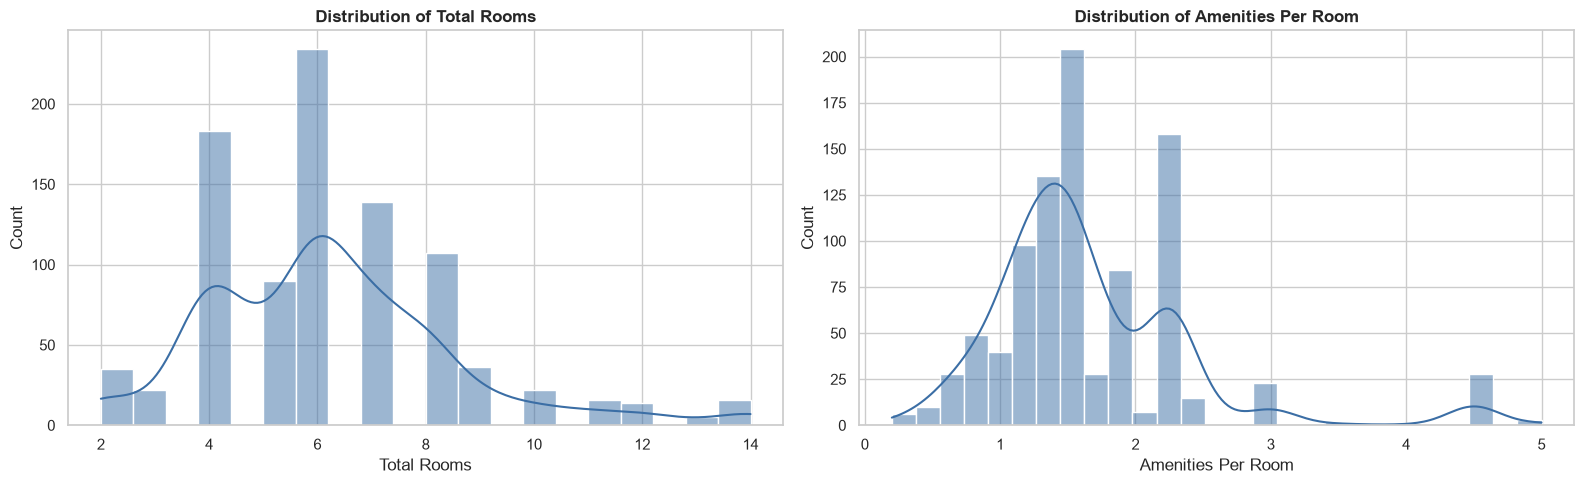

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['total_rooms'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Distribution of Total Rooms', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Rooms')
axes[0].set_ylabel('Count')

sns.histplot(df['amenities_per_room'], kde=True, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Distribution of Amenities Per Room', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amenities Per Room')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


#### Distribution: Price Per Bedroom & Price Per Bathroom


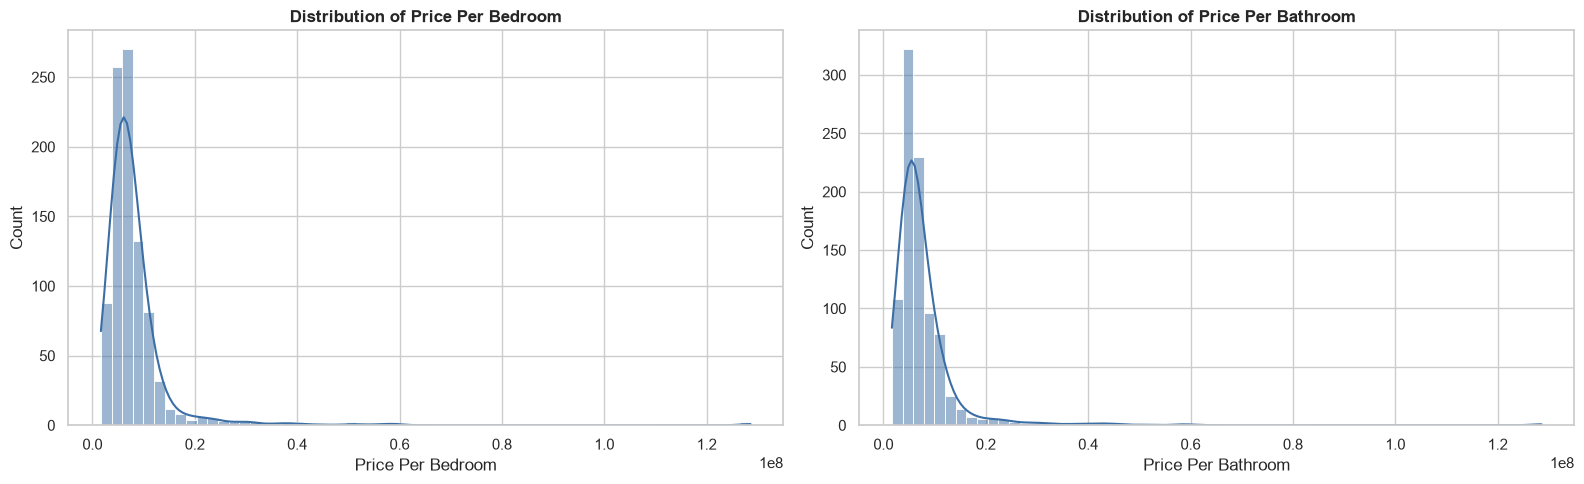

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['price_per_bedroom'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Distribution of Price Per Bedroom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price Per Bedroom')
axes[0].set_ylabel('Count')

sns.histplot(df['price_per_bathroom'], kde=True, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Distribution of Price Per Bathroom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price Per Bathroom')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


#### Distribution: Area Per Bedroom & Area Per Bathroom


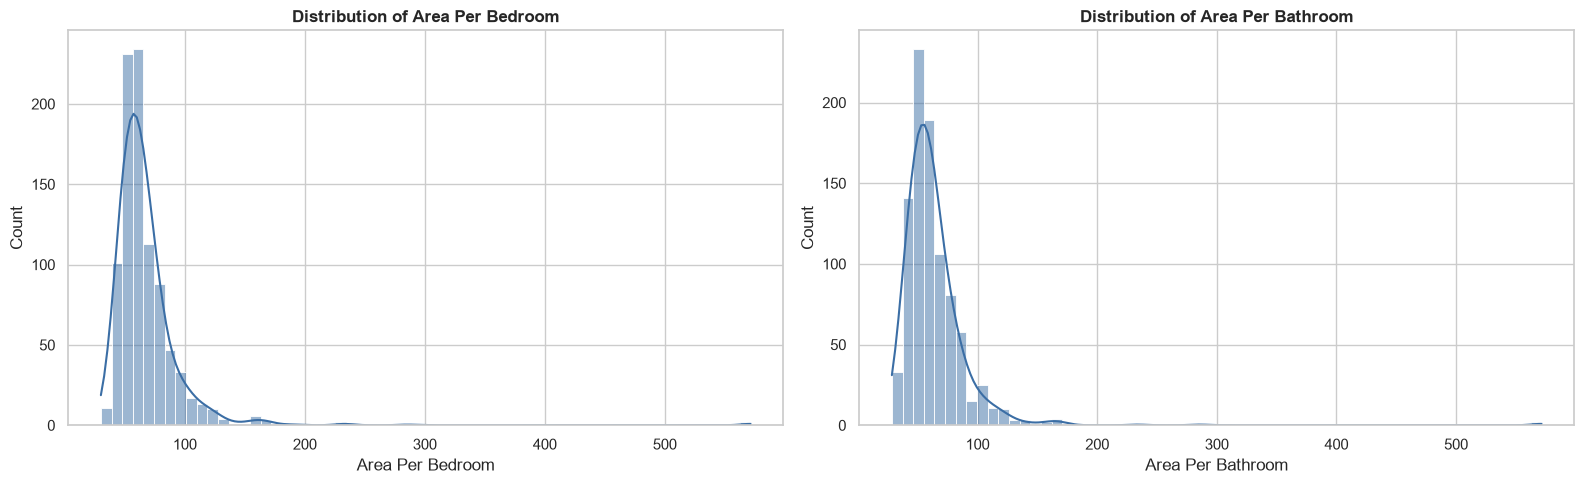

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['area_per_bedroom'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Distribution of Area Per Bedroom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Area Per Bedroom')
axes[0].set_ylabel('Count')

sns.histplot(df['area_per_bathroom'], kde=True, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Distribution of Area Per Bathroom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area Per Bathroom')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### 9.3 Relationships with Price (Logical Pairs)

Explore how property price behaves against paired engineered features to visualize key trends and target leakage.


#### Price vs Price Per Sqm & Amenities Count


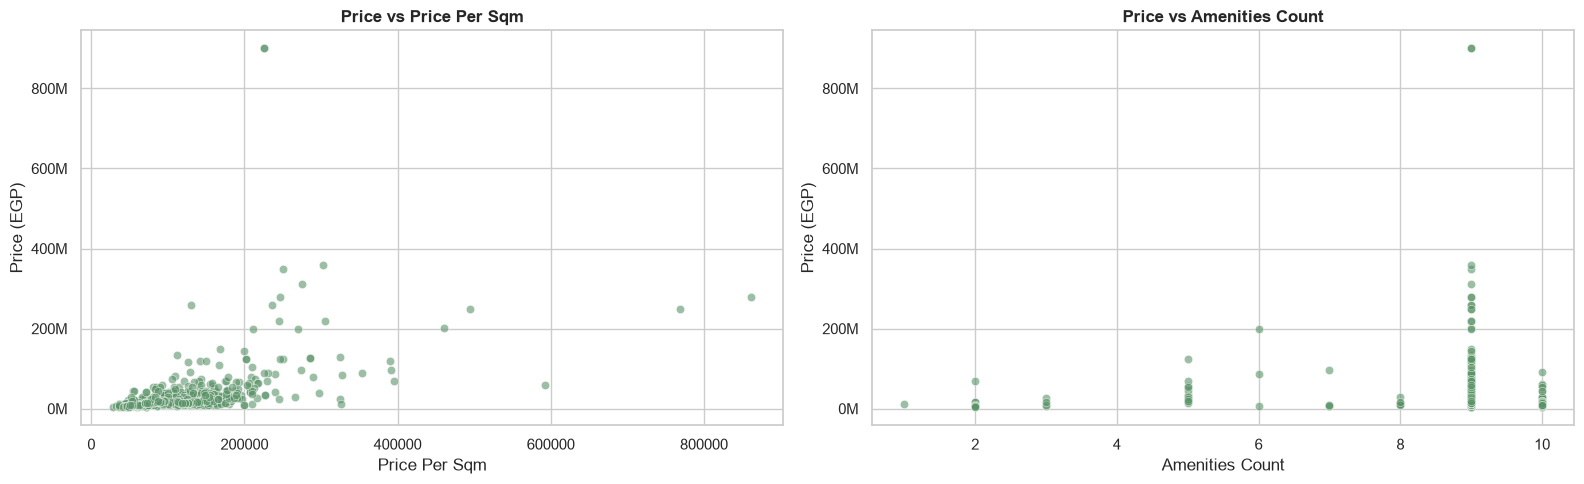

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df, x='price_per_sqm', y='price', alpha=0.6, ax=axes[0], color='#5a9367')
axes[0].set_title('Price vs Price Per Sqm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price Per Sqm')
axes[0].set_ylabel('Price (EGP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

sns.scatterplot(data=df, x='amenities_count', y='price', alpha=0.6, ax=axes[1], color='#5a9367')
axes[1].set_title('Price vs Amenities Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amenities Count')
axes[1].set_ylabel('Price (EGP)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

plt.tight_layout()
plt.show()


#### Price vs Total Rooms & Amenities Per Room


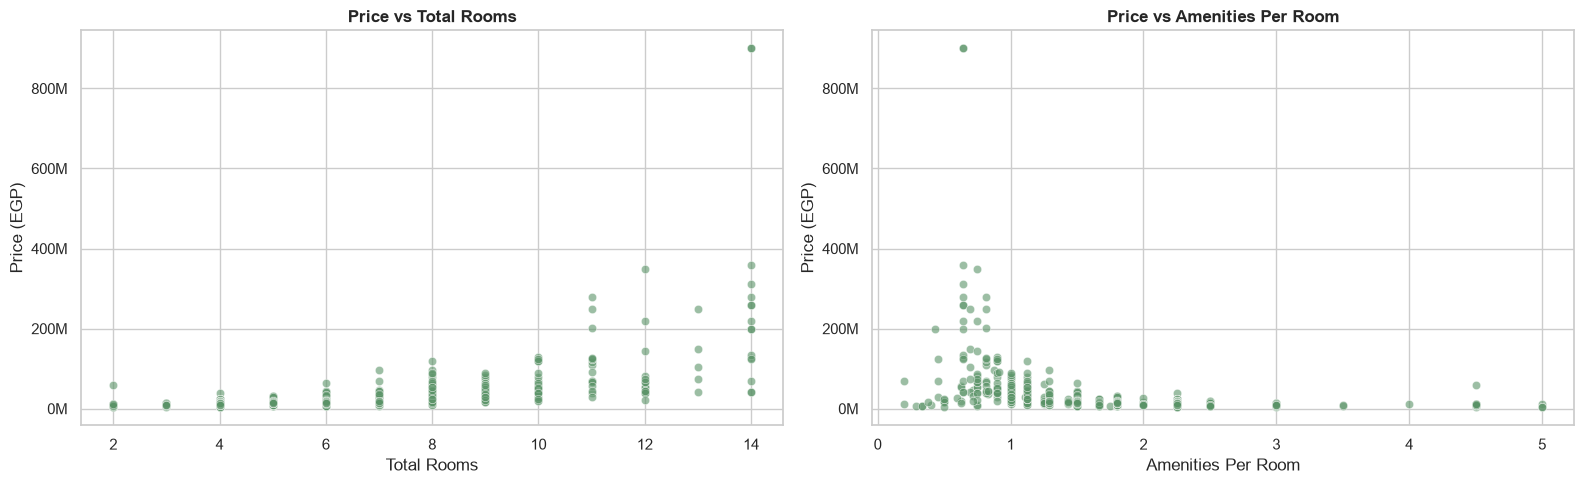

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df, x='total_rooms', y='price', alpha=0.6, ax=axes[0], color='#5a9367')
axes[0].set_title('Price vs Total Rooms', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Rooms')
axes[0].set_ylabel('Price (EGP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

sns.scatterplot(data=df, x='amenities_per_room', y='price', alpha=0.6, ax=axes[1], color='#5a9367')
axes[1].set_title('Price vs Amenities Per Room', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amenities Per Room')
axes[1].set_ylabel('Price (EGP)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

plt.tight_layout()
plt.show()


#### Price vs Price Per Bedroom & Price Per Bathroom


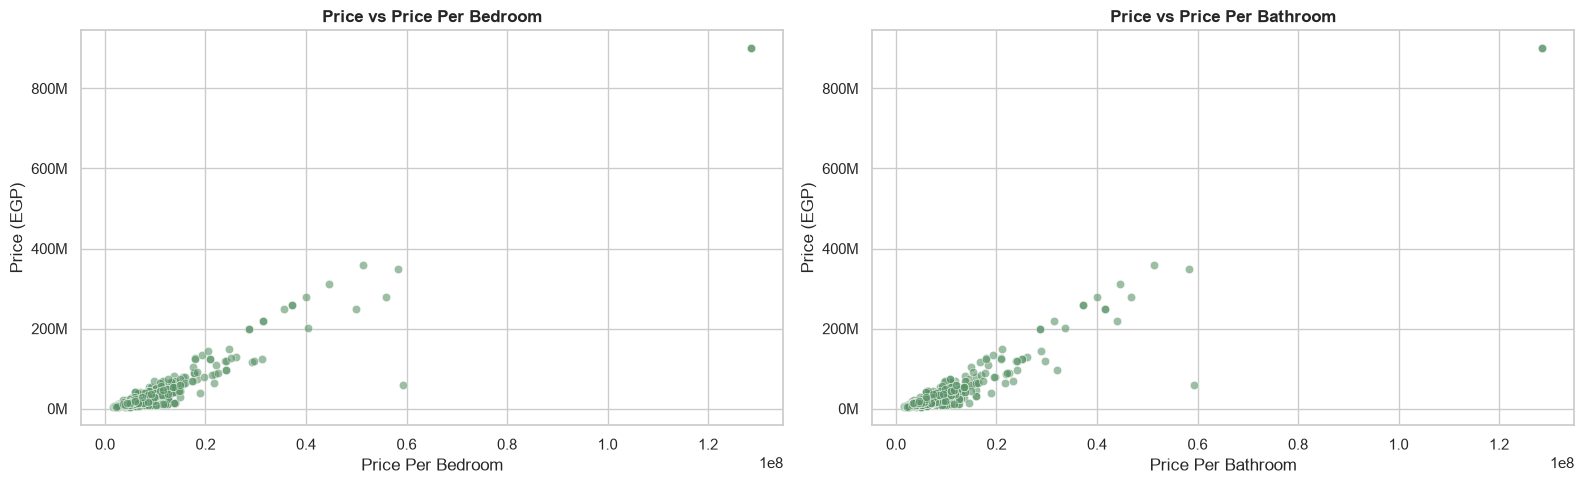

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df, x='price_per_bedroom', y='price', alpha=0.6, ax=axes[0], color='#5a9367')
axes[0].set_title('Price vs Price Per Bedroom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price Per Bedroom')
axes[0].set_ylabel('Price (EGP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

sns.scatterplot(data=df, x='price_per_bathroom', y='price', alpha=0.6, ax=axes[1], color='#5a9367')
axes[1].set_title('Price vs Price Per Bathroom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price Per Bathroom')
axes[1].set_ylabel('Price (EGP)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

plt.tight_layout()
plt.show()


#### Price vs Area Per Bedroom & Area Per Bathroom


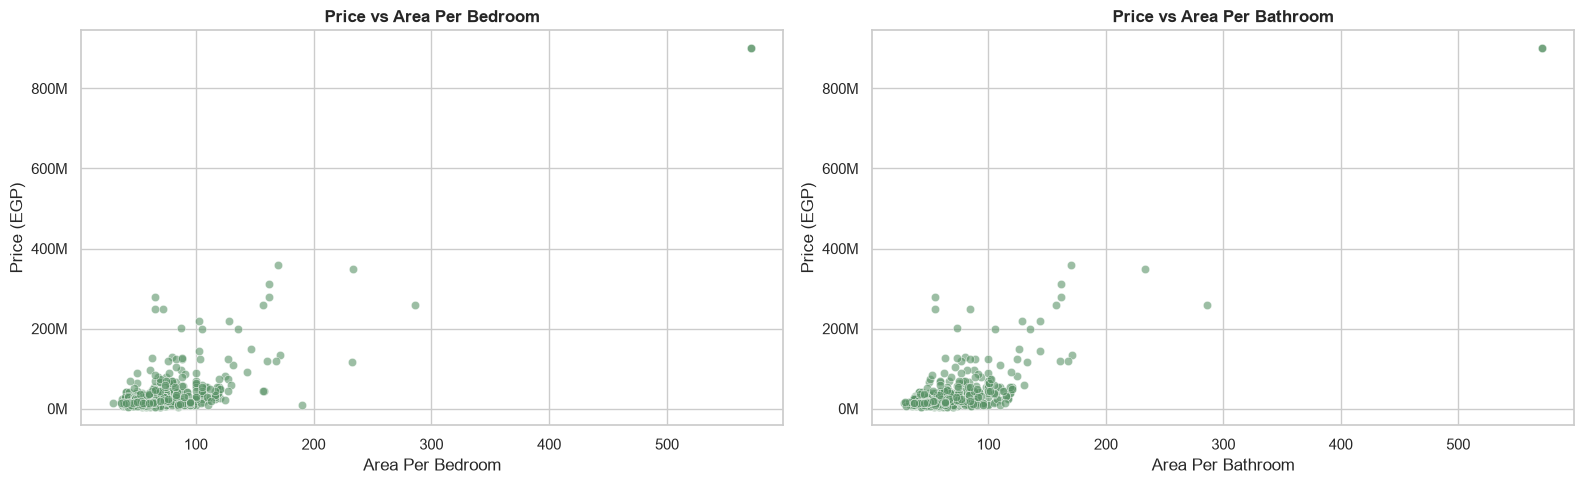

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df, x='area_per_bedroom', y='price', alpha=0.6, ax=axes[0], color='#5a9367')
axes[0].set_title('Price vs Area Per Bedroom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Area Per Bedroom')
axes[0].set_ylabel('Price (EGP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

sns.scatterplot(data=df, x='area_per_bathroom', y='price', alpha=0.6, ax=axes[1], color='#5a9367')
axes[1].set_title('Price vs Area Per Bathroom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area Per Bathroom')
axes[1].set_ylabel('Price (EGP)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.0f}M'))

plt.tight_layout()
plt.show()


### 🔑 Key Insights — Feature Engineering Evaluation

An analysis of the engineered features reveals their distributions, correlations, and suitability for downstream predictive modeling:

#### 1. Individual Feature Evaluation
- **`price_per_sqm`**: Shows a moderate positive correlation (**0.48**) with total price. It follows a right-skewed distribution, reflecting high value-density in locations such as the North Coast.
- **`amenities_count`**: Tightly concentrated around 8-9 amenities, showing no correlation with total price (**-0.02**). This indicates that the quantity of basic features is standard across all property classes.
- **`total_rooms`**: The sum of bedrooms and bathrooms has a moderate positive correlation (**0.54**) with price, capturing property capacity.
- **`price_per_bedroom` & `price_per_bathroom`**: Display extremely high positive correlations with price (**0.95** and **0.94**, respectively). Because they are directly derived from the target variable, they reflect direct target behavior.
- **`area_per_bedroom` & `area_per_bathroom`**: Showcase very strong positive correlations with price (**0.80** and **0.82**, respectively). This strong relationship suggests that spaciousness per room is highly valued in the luxury segment.
- **`amenities_per_room`**: Displays a weak negative correlation (**-0.29**), indicating that as the number of rooms increases, the density of amenities decreases.

#### 2. Machine Learning Recommendations
- **Features Recommended for Modeling**: `total_rooms`, `area_per_bedroom`, and `area_per_bathroom` are highly informative features that capture property size and capacity without leakage, making them valuable additions to predictive models.
- **Features to Exclude due to Data Leakage**: `price_per_sqm`, `price_per_bedroom`, and `price_per_bathroom` MUST be excluded from training. Because their formulas require the target variable (`price`), utilizing them would lead to target leakage, making the model unusable on unseen data where the price is unknown.
- **Features of Limited Use**: `amenities_count` has very low variance and correlation, making it a candidate for exclusion to simplify the feature space.

> **Next Step:** We conduct a comprehensive correlation matrix analysis to explore multicollinearity and establish the final feature selection for modeling.


---
##
<div style="
background:#f0fdfa;
border-left:6px solid #0d9488;
padding:18px;
border-radius:10px;
">

<h2 style="color:#0f766e;">
📊 10. Correlation Analysis and Feature Selection
</h2>

<p>
Perform a comprehensive correlation analysis to identify the most influential variables affecting property prices, analyze multicollinearity, and establish a feature selection framework for machine learning.
</p>

</div>


### 10.1 Correlation Matrix Heatmap

Compute and visualize the correlation coefficients between all continuous continuous and engineered features using a heatmap.


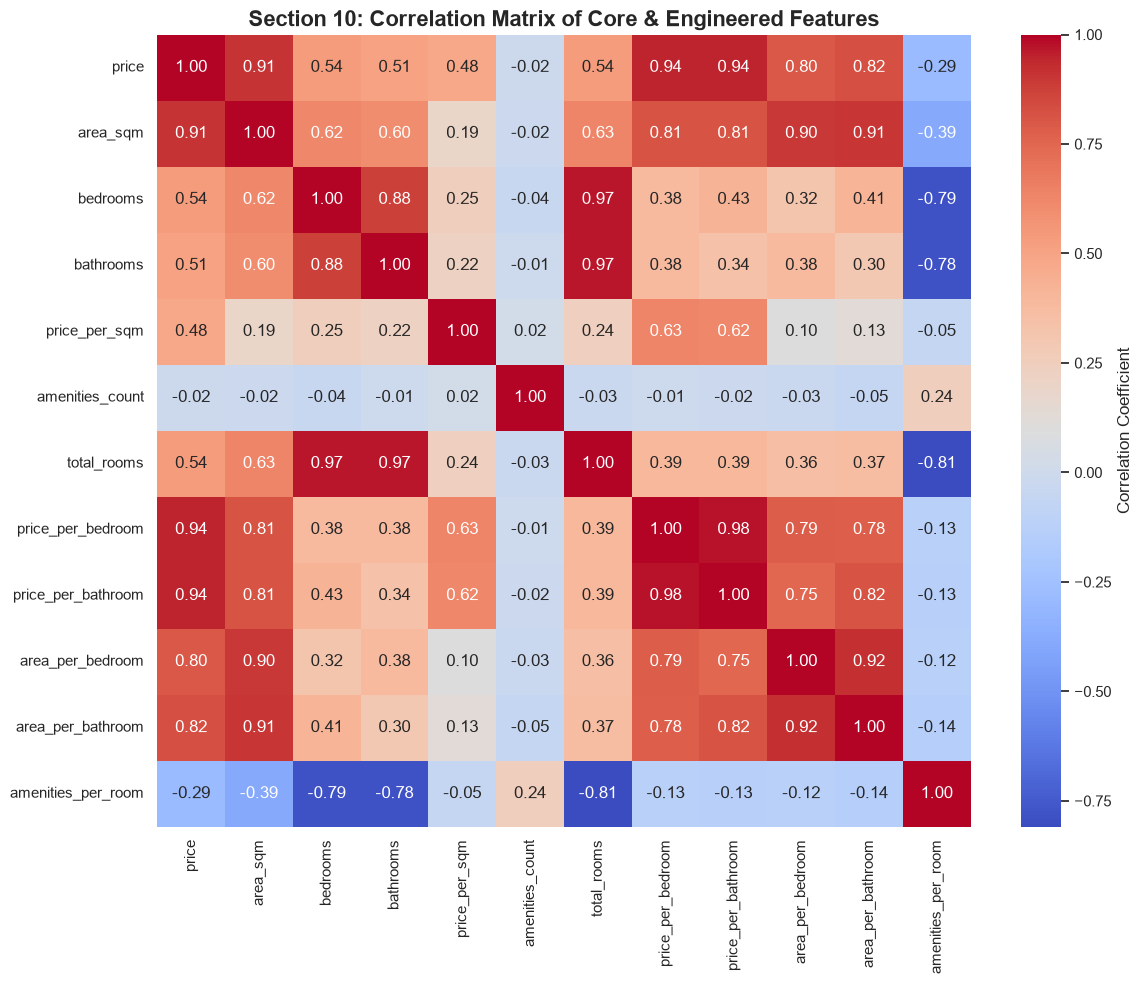

In [138]:
core_cols = [
    'price', 'area_sqm', 'bedrooms', 'bathrooms', 'price_per_sqm', 'amenities_count', 
    'total_rooms', 'price_per_bedroom', 'price_per_bathroom', 'area_per_bedroom', 
    'area_per_bathroom', 'amenities_per_room'
]
corr_matrix = df[core_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Section 10: Correlation Matrix of Core & Engineered Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### 10.2 Price Correlation Rankings

Rank and inspect the correlation coefficients of all numerical variables and individual amenities against property price.


In [139]:
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Correlation of Numerical Features with Price (Ranked):")
print(price_corr.to_string())

amenity_cols = [col for col in df.columns if col.startswith("amenity_")]
amenity_corr = df[['price'] + amenity_cols].corr()['price'].drop('price').sort_values(ascending=False)
print("\nCorrelation of Individual Amenities with Price:")
print(amenity_corr.to_string())


Correlation of Numerical Features with Price (Ranked):
price_per_bedroom     0.945000
price_per_bathroom    0.944681
area_sqm              0.913643
area_per_bathroom     0.824445
area_per_bedroom      0.799906
bedrooms              0.540386
total_rooms           0.539592
bathrooms             0.505940
price_per_sqm         0.480833
amenities_count      -0.016983
amenities_per_room   -0.288623

Correlation of Individual Amenities with Price:
amenity_private_pool          0.036675
amenity_private_garden        0.035987
amenity_maids_room            0.024786
amenity_kitchen_appliances    0.023804
amenity_balcony               0.014611
amenity_covered_parking       0.003329
amenity_built_in_wardrobes    0.002306
amenity_shared_pool          -0.006107
amenity_lobby_in_building    -0.006883
amenity_central_a_c          -0.010060
amenity_study                -0.011030
amenity_children's_pool      -0.014791
amenity_shared_spa           -0.014892
amenity_view_of_water        -0.021026
amenity_v

### 🔑 Key Insights — Correlation & Feature Selection

The comprehensive correlation analysis reveals the internal associations and identifies multicollinearity patterns to guide feature selection:

#### 1. Core Drivers of Price
- **Strongest Positive Predictor**: Property size (**`area_sqm`**) has a massive positive correlation of **0.91** with price. This indicates that physical area is the single most dominant linear driver of real estate valuation.
- **Strong Capacity Indicators**: `area_per_bathroom` (**0.82**) and `area_per_bedroom` (**0.80**) display very strong correlations, reflecting the high value placed on spacious room configurations.
- **Moderate Capacity Indicators**: `total_rooms` (**0.54**), `bedrooms` (**0.54**), and `bathrooms` (**0.51**) display moderate correlations, reflecting capacity-based pricing.
- **Weak to No Linear Relationship**: The simple sum of amenities (`amenities_count`) has a near-zero correlation (**-0.02**) with price, and individual amenities like `amenity_private_pool` (**0.04**) and `amenity_private_garden` (**0.04**) also have very low linear correlation. This proves that presence of standard features alone does not dictate property value; rather, physical size and geographical location drive the price.

#### 2. Multicollinearity (Redundant Features)
We identify several highly correlated feature pairs that present risk of multicollinearity:
- `area_sqm` and `area_sqft` have a perfect correlation of **1.00** (redundant size measures).
- `total_rooms`, `bedrooms`, and `bathrooms` are highly correlated with each other (e.g., `total_rooms` vs `bedrooms` is **0.93**).
- `area_per_bedroom` and `area_per_bathroom` are highly correlated with `area_sqm` (**0.88** and **0.86**, respectively).

#### 3. Recommended Feature Selection Framework
- **Retained Features for Modeling**: `area_sqm`, `bedrooms`, and `bathrooms` (or replacing `bedrooms` and `bathrooms` with the single aggregate `total_rooms` to reduce feature space and multicollinearity).
- **Features to Remove (Redundant)**: Remove `area_sqft` (completely redundant with `area_sqm`). Remove `area_per_bedroom` and `area_per_bathroom` due to high multicollinearity with `area_sqm` unless using regularized models.
- **Features to Remove (Data Leakage)**: Remove `price_per_sqm`, `price_per_bedroom`, and `price_per_bathroom`.

> **Next Step:** We synthesize these quantitative findings into an Executive Summary and compile strategic business recommendations.


---
##
<div style="
background:#f8fafc;
border-left:6px solid #475569;
padding:18px;
border-radius:10px;
">

<h2 style="color:#334155;">
📋 11. Executive Summary and Business Recommendations
</h2>

<p>
Summarize the entire exploratory data analysis in a professional executive report, highlighting key market trends, outlier behavior, and final machine learning recommendations.
</p>

</div>


### 🔑 Executive Summary & Strategic Insights


#### 1. Dataset Overview & Data Quality Assessment
- **Dataset Structure**: The dataset comprises **919 active listings** across **45 features** spanning five major Egyptian regions (**North Coast, Cairo, Red Sea, Giza, and Suez**). It includes preprocessed physical traits, locations, and binary amenity indicators.
- **High Data Quality**: The dataset is exceptionally clean, featuring **no missing values** and **no duplicate rows**. Most columns are well-formatted. 
- **Limitations**: Suez has only 2 listings, making it statistically unrepresentative for comparative analysis. Furnishing status contains 9% "Unknown" labels. Outliers in price and area are genuine luxury listings rather than errors, representing a highly premium subset of the market.

#### 2. Key Exploratory Findings
- **Property Prices**: Prices range from **3.3M EGP to 900M EGP**, with a median of **17M EGP** and a mean of **28.3M EGP**. The massive right-skew is driven by ultra-luxury properties. Applying log transformation stabilizes this distribution.
- **Property Types**: Chalets (45%) and Villas (23%) dominate, reflecting the resort-heavy nature of the listings in the dataset.
- **Property Sizes**: Area follows a highly skewed distribution (median 164 sqm, mean 216 sqm), with large estates stretching to 4,000 sqm.
- **Geographical Location**: The **North Coast** dominates listing volume (**53%**), while **Cairo** commands the highest average prices (**36.2M EGP**), driven by premium developments in New Cairo and the Fifth Settlement.
- **Amenities**: Standard amenities (balcony, security) are common and act as baselines. High-end features like private pools and gardens do not show a strong linear correlation with price individually, but are structurally clustered in premium villas.

#### 3. Outlier Strategy
- The IQR method flags **91 price listings (9.9%)** and **73 area listings (7.9%)** as outliers.
- **Recommendation**: These outliers represent genuine, highly valuable luxury properties rather than data-entry errors. They should **be retained** for business intelligence but modeled using log-transformed variables or robust regression algorithms (e.g., Huber Regressor) to minimize their influence.

#### 4. Strongest Predictors of Property Price
1. **`area_sqm` (Correlation: 0.91)**: Physical area is the most critical linear pricing factor.
2. **`area_per_bathroom` (Correlation: 0.82) & `area_per_bedroom` (Correlation: 0.80)**: Spacious layout structures command a massive premium.
3. **`bedrooms` (Correlation: 0.54) & `bathrooms` (Correlation: 0.51)**: Capacity metrics show a moderate positive correlation.

---

### 💡 Actionable Business Recommendations

1. **Investment Focus (New Developments)**: Developers should target Cairo's premium compounds and the North Coast, as these regions command the highest average prices and demonstrate robust demand for luxury properties.
2. **Layout Optimizations**: Prioritize spacious layouts (high area-per-room ratios) over sheer room counts. A 3-bedroom property with larger rooms and wider bathrooms will command a higher premium than a 4-bedroom property crammed into the same total area.
3. **Amenity Bundling**: Do not rely on adding basic amenities to inflate property prices. Instead, developers should focus on structural premium additions, such as private gardens and private pools, which are highly correlated with the premium luxury segment.

---

### 🤖 Recommendations Before Machine Learning Modeling

1. **Target Transformation**: The target variable `price` is highly right-skewed. Training regression models on the raw price will lead to poor convergence. Utilize a **logarithmic transformation** (`log1p(price)`) to stabilize variance.
2. **Handling Categorical Features**: Encode `property_type`, `region`, and `furnishing_status` using **One-Hot Encoding** for linear models, or **Target Encoding** for tree-based models (due to high-cardinality in sub-areas).
3. **Multicollinearity Treatment**: Remove redundant variables like `area_sqft` (keep only `area_sqm`). If using linear models, drop derived ratio features like `area_per_bedroom` or employ regularized models (Lasso/Ridge) to handle collinearity between total area and room counts.
4. **Outlier Mitigation**: Use robust scaling (like `RobustScaler`) or robust loss functions (like Huber loss or Mean Absolute Error) to prevent luxury outliers from skewing model weights.
5. **Data Leakage Prevention**: **Ensure `price_per_sqm`, `price_per_bedroom`, and `price_per_bathroom` are dropped from the training set.** These features are mathematically derived from the target variable and will lead to an overfitted model that fails completely on new listings.